In [108]:
# DATA TRANSFORMATION & FEATURE ENGINEERING

In [109]:
import pandas as pd
import numpy as np

df = pd.read_csv('C:/Users/pc/Desktop/python/Dataset(s)/supply_chain_dataset.csv')
pd.set_option('display.max_columns',50)
df.head()

,order_id,order_date,product_category,quantity,unit_price,total_cost,supplier_name,supplier_location,lead_time_days,warehouse_destination,delivery_date,actual_delivery_days,delivery_status,on_time,product_defects,return_status
0,ORD-0001,11/28/2022,Fasteners,94,64.49,6062.06,SupplierE,Mexico,32,Warehouse_3,2022-12-30,32,Delayed,Yes,0.0,No Return
1,ORD-0002,2022-02-20,Fasteners,16,76.63,1226.08,Supplier E,Mexico,17,Warehouse_2,2022-03-09,17,Delivered,Yes,2.0,Partial Return
2,ORD-0003,2022-11-03,Control Systems,25,2159.06,53976.50,Supplier A,USA,17,Warehouse_1,2022-11-20,17,Delivered,Yes,0.0,NaN
3,ORD-0004,2022-12-15,Valves,33,774.64,25563.12,supplierc,China,36,Warehouse_1,2023-01-20,36,Delivered,Yes,0.0,No Return
4,ORD-0005,2022-03-02,Motors,13,2091.41,27188.33,supplierb,Germany,15,Warehouse_6,2022-03-17,15,Delivered,Yes,0.0,No Return


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               3000 non-null   object 
 1   order_date             3000 non-null   object 
 2   product_category       3000 non-null   object 
 3   quantity               3000 non-null   int64  
 4   unit_price             3000 non-null   float64
 5   total_cost             3000 non-null   float64
 6   supplier_name          3000 non-null   object 
 7   supplier_location      3000 non-null   object 
 8   lead_time_days         3000 non-null   int64  
 9   warehouse_destination  3000 non-null   object 
 10  delivery_date          3000 non-null   object 
 11  actual_delivery_days   3000 non-null   int64  
 12  delivery_status        3000 non-null   object 
 13  on_time                3000 non-null   object 
 14  product_defects        2846 non-null   float64
 15  retu

In [111]:

df = df.drop_duplicates()

In [112]:
print(len(df))

3000


In [113]:
df.dtypes

order_id                  object
order_date                object
product_category          object
quantity                   int64
unit_price               float64
total_cost               float64
supplier_name             object
supplier_location         object
lead_time_days             int64
warehouse_destination     object
delivery_date             object
actual_delivery_days       int64
delivery_status           object
on_time                   object
product_defects          float64
return_status             object
dtype: object

In [114]:
#Task 1: Handle Missing Values

In [115]:
# Find which columns have missing values
df.columns[df.isnull().any()]

Index(['product_defects', 'return_status'], dtype='object')

In [116]:
#Count how many missing values in each column
df.isnull().sum()

order_id                   0
order_date                 0
product_category           0
quantity                   0
unit_price                 0
total_cost                 0
supplier_name              0
supplier_location          0
lead_time_days             0
warehouse_destination      0
delivery_date              0
actual_delivery_days       0
delivery_status            0
on_time                    0
product_defects          154
return_status            146
dtype: int64

In [117]:
#For columns with few missing values: fill them (use mean for numbers, most common value for text)
AVG_product_defects = df['product_defects'].mean()
df['product_defects']= df['product_defects'].fillna(AVG_product_defects)
df['return_status']= df['return_status'].fillna("Unknown")


In [118]:
df.isnull().sum()

order_id                 0
order_date               0
product_category         0
quantity                 0
unit_price               0
total_cost               0
supplier_name            0
supplier_location        0
lead_time_days           0
warehouse_destination    0
delivery_date            0
actual_delivery_days     0
delivery_status          0
on_time                  0
product_defects          0
return_status            0
dtype: int64

In [119]:
#Task 2: Convert Data Types

In [120]:
#Check the current data type of each column
df.dtypes

order_id                  object
order_date                object
product_category          object
quantity                   int64
unit_price               float64
total_cost               float64
supplier_name             object
supplier_location         object
lead_time_days             int64
warehouse_destination     object
delivery_date             object
actual_delivery_days       int64
delivery_status           object
on_time                   object
product_defects          float64
return_status             object
dtype: object

In [121]:
#Convert date columns to datetime (so you can do date calculations)
df['order_date'] = pd.to_datetime(df['order_date'], format = 'mixed')
df['delivery_date'] = pd.to_datetime(df['delivery_date'],format = 'mixed')

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               3000 non-null   object        
 1   order_date             3000 non-null   datetime64[ns]
 2   product_category       3000 non-null   object        
 3   quantity               3000 non-null   int64         
 4   unit_price             3000 non-null   float64       
 5   total_cost             3000 non-null   float64       
 6   supplier_name          3000 non-null   object        
 7   supplier_location      3000 non-null   object        
 8   lead_time_days         3000 non-null   int64         
 9   warehouse_destination  3000 non-null   object        
 10  delivery_date          3000 non-null   datetime64[ns]
 11  actual_delivery_days   3000 non-null   int64         
 12  delivery_status        3000 non-null   object        
 13  on_

In [123]:
df.head()

,order_id,order_date,product_category,quantity,unit_price,total_cost,supplier_name,supplier_location,lead_time_days,warehouse_destination,delivery_date,actual_delivery_days,delivery_status,on_time,product_defects,return_status
0,ORD-0001,2022-11-28,Fasteners,94,64.49,6062.06,SupplierE,Mexico,32,Warehouse_3,2022-12-30,32,Delayed,Yes,0.0,No Return
1,ORD-0002,2022-02-20,Fasteners,16,76.63,1226.08,Supplier E,Mexico,17,Warehouse_2,2022-03-09,17,Delivered,Yes,2.0,Partial Return
2,ORD-0003,2022-11-03,Control Systems,25,2159.06,53976.50,Supplier A,USA,17,Warehouse_1,2022-11-20,17,Delivered,Yes,0.0,Unknown
3,ORD-0004,2022-12-15,Valves,33,774.64,25563.12,supplierc,China,36,Warehouse_1,2023-01-20,36,Delivered,Yes,0.0,No Return
4,ORD-0005,2022-03-02,Motors,13,2091.41,27188.33,supplierb,Germany,15,Warehouse_6,2022-03-17,15,Delivered,Yes,0.0,No Return


In [124]:
#Task 3: Create Simple Calculated Columns

In [125]:
#Column 1: Days to Deliver
#Subtract order_date from delivery_date to get number of days

df['days_to_deliver'] = (df['delivery_date'] -df['order_date'])/pd.Timedelta(days=1)
df.head()

,order_id,order_date,product_category,quantity,unit_price,total_cost,supplier_name,supplier_location,lead_time_days,warehouse_destination,delivery_date,actual_delivery_days,delivery_status,on_time,product_defects,return_status,days_to_deliver
0,ORD-0001,2022-11-28,Fasteners,94,64.49,6062.06,SupplierE,Mexico,32,Warehouse_3,2022-12-30,32,Delayed,Yes,0.0,No Return,32.0
1,ORD-0002,2022-02-20,Fasteners,16,76.63,1226.08,Supplier E,Mexico,17,Warehouse_2,2022-03-09,17,Delivered,Yes,2.0,Partial Return,17.0
2,ORD-0003,2022-11-03,Control Systems,25,2159.06,53976.50,Supplier A,USA,17,Warehouse_1,2022-11-20,17,Delivered,Yes,0.0,Unknown,17.0
3,ORD-0004,2022-12-15,Valves,33,774.64,25563.12,supplierc,China,36,Warehouse_1,2023-01-20,36,Delivered,Yes,0.0,No Return,36.0
4,ORD-0005,2022-03-02,Motors,13,2091.41,27188.33,supplierb,Germany,15,Warehouse_6,2022-03-17,15,Delivered,Yes,0.0,No Return,15.0


In [126]:
#Column 2: Order Size Category
# • If quantity < 50: "Small"
# • If quantity 50-200: "Medium"
# • If quantity > 200: "Large"
# • This groups orders by size

def size_category(q):
    if q <50:
        return 'small'
    elif 50<=q<=200:
        return 'medium'
    else:
        return 'large'
df['size_category'] = df['quantity'].apply(size_category)
df.head()

,order_id,order_date,product_category,quantity,unit_price,total_cost,supplier_name,supplier_location,lead_time_days,warehouse_destination,delivery_date,actual_delivery_days,delivery_status,on_time,product_defects,return_status,days_to_deliver,size_category
0,ORD-0001,2022-11-28,Fasteners,94,64.49,6062.06,SupplierE,Mexico,32,Warehouse_3,2022-12-30,32,Delayed,Yes,0.0,No Return,32.0,medium
1,ORD-0002,2022-02-20,Fasteners,16,76.63,1226.08,Supplier E,Mexico,17,Warehouse_2,2022-03-09,17,Delivered,Yes,2.0,Partial Return,17.0,small
2,ORD-0003,2022-11-03,Control Systems,25,2159.06,53976.50,Supplier A,USA,17,Warehouse_1,2022-11-20,17,Delivered,Yes,0.0,Unknown,17.0,small
3,ORD-0004,2022-12-15,Valves,33,774.64,25563.12,supplierc,China,36,Warehouse_1,2023-01-20,36,Delivered,Yes,0.0,No Return,36.0,small
4,ORD-0005,2022-03-02,Motors,13,2091.41,27188.33,supplierb,Germany,15,Warehouse_6,2022-03-17,15,Delivered,Yes,0.0,No Return,15.0,small


In [127]:
# Column 3: High Cost Flag
# • If total_cost > average total_cost: 1 (True)
# # • Otherwise: 0 (False

AVG_cost = df['total_cost'].mean()
df['high_cost_flag'] = (df['total_cost'] > AVG_cost).astype(int)

#df['high_cost_flag'] = (df['total_cost']>df['total_cost'].mean()).astype(int)
df.head()

,order_id,order_date,product_category,quantity,unit_price,total_cost,supplier_name,supplier_location,lead_time_days,warehouse_destination,delivery_date,actual_delivery_days,delivery_status,on_time,product_defects,return_status,days_to_deliver,size_category,high_cost_flag
0,ORD-0001,2022-11-28,Fasteners,94,64.49,6062.06,SupplierE,Mexico,32,Warehouse_3,2022-12-30,32,Delayed,Yes,0.0,No Return,32.0,medium,0
1,ORD-0002,2022-02-20,Fasteners,16,76.63,1226.08,Supplier E,Mexico,17,Warehouse_2,2022-03-09,17,Delivered,Yes,2.0,Partial Return,17.0,small,0
2,ORD-0003,2022-11-03,Control Systems,25,2159.06,53976.50,Supplier A,USA,17,Warehouse_1,2022-11-20,17,Delivered,Yes,0.0,Unknown,17.0,small,0
3,ORD-0004,2022-12-15,Valves,33,774.64,25563.12,supplierc,China,36,Warehouse_1,2023-01-20,36,Delivered,Yes,0.0,No Return,36.0,small,0
4,ORD-0005,2022-03-02,Motors,13,2091.41,27188.33,supplierb,Germany,15,Warehouse_6,2022-03-17,15,Delivered,Yes,0.0,No Return,15.0,small,0


In [128]:
# Task 4: Clean Up Text Data

In [129]:
# Remove extra spaces from supplier_name and product_name
df['product_category'] = df['product_category'].str.strip()
df['supplier_name'] = df['supplier_name'].str.strip()
df.head()


# note: to remove for left side only .str.lstrip()
#     to remove for right side only .str.rstrip()

,order_id,order_date,product_category,quantity,unit_price,total_cost,supplier_name,supplier_location,lead_time_days,warehouse_destination,delivery_date,actual_delivery_days,delivery_status,on_time,product_defects,return_status,days_to_deliver,size_category,high_cost_flag
0,ORD-0001,2022-11-28,Fasteners,94,64.49,6062.06,SupplierE,Mexico,32,Warehouse_3,2022-12-30,32,Delayed,Yes,0.0,No Return,32.0,medium,0
1,ORD-0002,2022-02-20,Fasteners,16,76.63,1226.08,Supplier E,Mexico,17,Warehouse_2,2022-03-09,17,Delivered,Yes,2.0,Partial Return,17.0,small,0
2,ORD-0003,2022-11-03,Control Systems,25,2159.06,53976.50,Supplier A,USA,17,Warehouse_1,2022-11-20,17,Delivered,Yes,0.0,Unknown,17.0,small,0
3,ORD-0004,2022-12-15,Valves,33,774.64,25563.12,supplierc,China,36,Warehouse_1,2023-01-20,36,Delivered,Yes,0.0,No Return,36.0,small,0
4,ORD-0005,2022-03-02,Motors,13,2091.41,27188.33,supplierb,Germany,15,Warehouse_6,2022-03-17,15,Delivered,Yes,0.0,No Return,15.0,small,0


In [130]:
# Make all supplier_name values the same capitalization (all uppercase or title case)
df['supplier_name'].unique()

array(['SupplierE', 'Supplier E', 'Supplier A', 'supplierc', 'supplierb',
       'supplierd', 'suppliere', 'SupplierC', 'Supplier C', 'SupplierA',
       'Supplier D', 'suppliera', 'SupplierB', 'SupplierD', 'Supplier B'],
      dtype=object)

In [131]:
df['supplier_name'] = df['supplier_name'].str.replace("SupplierE","Supplier E")
df['supplier_name'] = df['supplier_name'].str.replace("supplierc","Supplier C")
df['supplier_name'] = df['supplier_name'].str.replace("supplierb","Supplier B")
df['supplier_name'] = df['supplier_name'].str.replace("SupplierA","Supplier A")
df['supplier_name'] = df['supplier_name'].str.replace("suppliera","Supplier A")
df['supplier_name'] = df['supplier_name'].str.replace("SupplierC","Supplier C")
df['supplier_name'] = df['supplier_name'].str.replace("supplierd","Supplier D")
df['supplier_name'] = df['supplier_name'].str.replace("SupplierB","Supplier B")
df['supplier_name'] = df['supplier_name'].str.replace("SupplierD","Supplier D")
df['supplier_name'] = df['supplier_name'].str.replace("suppliere","Supplier E")

df['supplier_name'].unique()

array(['Supplier E', 'Supplier A', 'Supplier C', 'Supplier B',
       'Supplier D'], dtype=object)

In [132]:
df['warehouse_destination'].unique()

array(['Warehouse_3', 'Warehouse_2', 'Warehouse_1', 'Warehouse_6',
       'Warehouse_4', 'WH_2', 'Warehouse_5', 'WH_6', 'WH_4', 'WH_5',
       'WH_3', 'WH_1'], dtype=object)

In [133]:
df['warehouse_destination']  = df['warehouse_destination'].str.replace('WH_2','Warehouse_2')
df['warehouse_destination']  = df['warehouse_destination'].str.replace('WH_6','Warehouse_6')
df['warehouse_destination']  = df['warehouse_destination'].str.replace('WH_4','Warehouse_4')
df['warehouse_destination']  = df['warehouse_destination'].str.replace('WH_5','Warehouse_5')
df['warehouse_destination']  = df['warehouse_destination'].str.replace('WH_3','Warehouse_3')
df['warehouse_destination']  = df['warehouse_destination'].str.replace('WH_1','Warehouse_1')

df['warehouse_destination'].unique()

array(['Warehouse_3', 'Warehouse_2', 'Warehouse_1', 'Warehouse_6',
       'Warehouse_4', 'Warehouse_5'], dtype=object)

In [134]:
# Check for spelling inconsistencies and fix any you find
# df['delivery_status'].unique()

In [135]:
df['delivery_status'] = df['delivery_status'].str.replace('Pendng', 'Pending')
df['delivery_status'] = df['delivery_status'].str.replace('Delievered', 'Delivered')
df['delivery_status'].unique()

array(['Delayed', 'Delivered', 'Cancelled', 'In-Transit', 'Pending'],
      dtype=object)

In [136]:
# Check for spelling inconsistencies (like "Motor" vs "Moter") and fix any you find

df['product_category'].unique()

array(['Fasteners', 'Control Systems', 'Valves', 'Motors', 'Sensors',
       'Pumps', 'Connectors', 'Hydraulics'], dtype=object)

In [137]:
# Task 5: Create Performance Metrics
#Create columns that show how well things performed.

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               3000 non-null   object        
 1   order_date             3000 non-null   datetime64[ns]
 2   product_category       3000 non-null   object        
 3   quantity               3000 non-null   int64         
 4   unit_price             3000 non-null   float64       
 5   total_cost             3000 non-null   float64       
 6   supplier_name          3000 non-null   object        
 7   supplier_location      3000 non-null   object        
 8   lead_time_days         3000 non-null   int64         
 9   warehouse_destination  3000 non-null   object        
 10  delivery_date          3000 non-null   datetime64[ns]
 11  actual_delivery_days   3000 non-null   int64         
 12  delivery_status        3000 non-null   object        
 13  on_

In [139]:
df['days_to_deliver'].dtype

dtype('float64')

In [140]:
# Column 1: On Time (1 or 0)
# • If days_to_deliver <= lead_time_days: 1 (on time)
# • Otherwise: 0 (late)
# # • This flags the orders that arrived on schedule

df['On Time'] = (df['days_to_deliver']<= df['lead_time_days']).astype(int)
df.head()

,order_id,order_date,product_category,quantity,unit_price,total_cost,supplier_name,supplier_location,lead_time_days,warehouse_destination,delivery_date,actual_delivery_days,delivery_status,on_time,product_defects,return_status,days_to_deliver,size_category,high_cost_flag,On Time
0,ORD-0001,2022-11-28,Fasteners,94,64.49,6062.06,Supplier E,Mexico,32,Warehouse_3,2022-12-30,32,Delayed,Yes,0.0,No Return,32.0,medium,0,1
1,ORD-0002,2022-02-20,Fasteners,16,76.63,1226.08,Supplier E,Mexico,17,Warehouse_2,2022-03-09,17,Delivered,Yes,2.0,Partial Return,17.0,small,0,1
2,ORD-0003,2022-11-03,Control Systems,25,2159.06,53976.50,Supplier A,USA,17,Warehouse_1,2022-11-20,17,Delivered,Yes,0.0,Unknown,17.0,small,0,1
3,ORD-0004,2022-12-15,Valves,33,774.64,25563.12,Supplier C,China,36,Warehouse_1,2023-01-20,36,Delivered,Yes,0.0,No Return,36.0,small,0,1
4,ORD-0005,2022-03-02,Motors,13,2091.41,27188.33,Supplier B,Germany,15,Warehouse_6,2022-03-17,15,Delivered,Yes,0.0,No Return,15.0,small,0,1


In [141]:
#column 2: Cost Per Unit
# • Divide total_cost by quantity
# • This shows the unit price
# • Helps compare if one order was more expensive per item
df['cost_per_unit'] = round(df['total_cost']/ df['quantity']).astype(int)
df.head()


,order_id,order_date,product_category,quantity,unit_price,total_cost,supplier_name,supplier_location,lead_time_days,warehouse_destination,delivery_date,actual_delivery_days,delivery_status,on_time,product_defects,return_status,days_to_deliver,size_category,high_cost_flag,On Time,cost_per_unit
0,ORD-0001,2022-11-28,Fasteners,94,64.49,6062.06,Supplier E,Mexico,32,Warehouse_3,2022-12-30,32,Delayed,Yes,0.0,No Return,32.0,medium,0,1,64
1,ORD-0002,2022-02-20,Fasteners,16,76.63,1226.08,Supplier E,Mexico,17,Warehouse_2,2022-03-09,17,Delivered,Yes,2.0,Partial Return,17.0,small,0,1,77
2,ORD-0003,2022-11-03,Control Systems,25,2159.06,53976.50,Supplier A,USA,17,Warehouse_1,2022-11-20,17,Delivered,Yes,0.0,Unknown,17.0,small,0,1,2159
3,ORD-0004,2022-12-15,Valves,33,774.64,25563.12,Supplier C,China,36,Warehouse_1,2023-01-20,36,Delivered,Yes,0.0,No Return,36.0,small,0,1,775
4,ORD-0005,2022-03-02,Motors,13,2091.41,27188.33,Supplier B,Germany,15,Warehouse_6,2022-03-17,15,Delivered,Yes,0.0,No Return,15.0,small,0,1,2091


In [142]:
# Column 3: Supplier Performance Grade
# • For each supplier, calculate their on-time delivery rate
supplier_per = round(df.groupby("supplier_name")['On Time'].mean()*100).reset_index()
supplier_per.rename(columns={'On Time':'delivery_rate'},inplace=True)

#drop column if it already exist to avoid duplicate
df = df.drop(columns=['delivery_rate'], errors='ignore')
# • Merge this back to each order
df = df.merge(supplier_per, on = "supplier_name", how='left')
# • This shows each supplier's overall reliability
df.head()

,order_id,order_date,product_category,quantity,unit_price,total_cost,supplier_name,supplier_location,lead_time_days,warehouse_destination,delivery_date,actual_delivery_days,delivery_status,on_time,product_defects,return_status,days_to_deliver,size_category,high_cost_flag,On Time,cost_per_unit,delivery_rate
0,ORD-0001,2022-11-28,Fasteners,94,64.49,6062.06,Supplier E,Mexico,32,Warehouse_3,2022-12-30,32,Delayed,Yes,0.0,No Return,32.0,medium,0,1,64,76.0
1,ORD-0002,2022-02-20,Fasteners,16,76.63,1226.08,Supplier E,Mexico,17,Warehouse_2,2022-03-09,17,Delivered,Yes,2.0,Partial Return,17.0,small,0,1,77,76.0
2,ORD-0003,2022-11-03,Control Systems,25,2159.06,53976.50,Supplier A,USA,17,Warehouse_1,2022-11-20,17,Delivered,Yes,0.0,Unknown,17.0,small,0,1,2159,95.0
3,ORD-0004,2022-12-15,Valves,33,774.64,25563.12,Supplier C,China,36,Warehouse_1,2023-01-20,36,Delivered,Yes,0.0,No Return,36.0,small,0,1,775,83.0
4,ORD-0005,2022-03-02,Motors,13,2091.41,27188.33,Supplier B,Germany,15,Warehouse_6,2022-03-17,15,Delivered,Yes,0.0,No Return,15.0,small,0,1,2091,89.0


In [143]:
# Create a "Delivery Speed Category" column: "Fast" (< 7 days), "Normal" (7-21 days), "Slow" 
# (> 21 days). 

def Delivery_Speed_Category(sp):
    if sp <7:
        return 'fast'
    elif 7<=sp<=21:
        return 'normal'
    else:
        return 'slow'
df['Delivery_Speed_Category'] = df['days_to_deliver'].apply(Delivery_Speed_Category)
df.head()

,order_id,order_date,product_category,quantity,unit_price,total_cost,supplier_name,supplier_location,lead_time_days,warehouse_destination,delivery_date,actual_delivery_days,delivery_status,on_time,product_defects,return_status,days_to_deliver,size_category,high_cost_flag,On Time,cost_per_unit,delivery_rate,Delivery_Speed_Category
0,ORD-0001,2022-11-28,Fasteners,94,64.49,6062.06,Supplier E,Mexico,32,Warehouse_3,2022-12-30,32,Delayed,Yes,0.0,No Return,32.0,medium,0,1,64,76.0,slow
1,ORD-0002,2022-02-20,Fasteners,16,76.63,1226.08,Supplier E,Mexico,17,Warehouse_2,2022-03-09,17,Delivered,Yes,2.0,Partial Return,17.0,small,0,1,77,76.0,normal
2,ORD-0003,2022-11-03,Control Systems,25,2159.06,53976.50,Supplier A,USA,17,Warehouse_1,2022-11-20,17,Delivered,Yes,0.0,Unknown,17.0,small,0,1,2159,95.0,normal
3,ORD-0004,2022-12-15,Valves,33,774.64,25563.12,Supplier C,China,36,Warehouse_1,2023-01-20,36,Delivered,Yes,0.0,No Return,36.0,small,0,1,775,83.0,slow
4,ORD-0005,2022-03-02,Motors,13,2091.41,27188.33,Supplier B,Germany,15,Warehouse_6,2022-03-17,15,Delivered,Yes,0.0,No Return,15.0,small,0,1,2091,89.0,normal


In [144]:
# How many orders fall into each category?
df['Delivery_Speed_Category'].value_counts()

Delivery_Speed_Category
normal    1437
slow      1401
fast       162
Name: count, dtype: int64

In [145]:
# Create a column showing how old each order is (days since order_date). Are older orders treated differently than newer ones?
today = pd.Timestamp.today()
df['order_age'] =round((today-df['order_date']).dt.days/365)
df.head()

,order_id,order_date,product_category,quantity,unit_price,total_cost,supplier_name,supplier_location,lead_time_days,warehouse_destination,delivery_date,actual_delivery_days,delivery_status,on_time,product_defects,return_status,days_to_deliver,size_category,high_cost_flag,On Time,cost_per_unit,delivery_rate,Delivery_Speed_Category,order_age
0,ORD-0001,2022-11-28,Fasteners,94,64.49,6062.06,Supplier E,Mexico,32,Warehouse_3,2022-12-30,32,Delayed,Yes,0.0,No Return,32.0,medium,0,1,64,76.0,slow,4.0
1,ORD-0002,2022-02-20,Fasteners,16,76.63,1226.08,Supplier E,Mexico,17,Warehouse_2,2022-03-09,17,Delivered,Yes,2.0,Partial Return,17.0,small,0,1,77,76.0,normal,4.0
2,ORD-0003,2022-11-03,Control Systems,25,2159.06,53976.50,Supplier A,USA,17,Warehouse_1,2022-11-20,17,Delivered,Yes,0.0,Unknown,17.0,small,0,1,2159,95.0,normal,4.0
3,ORD-0004,2022-12-15,Valves,33,774.64,25563.12,Supplier C,China,36,Warehouse_1,2023-01-20,36,Delivered,Yes,0.0,No Return,36.0,small,0,1,775,83.0,slow,4.0
4,ORD-0005,2022-03-02,Motors,13,2091.41,27188.33,Supplier B,Germany,15,Warehouse_6,2022-03-17,15,Delivered,Yes,0.0,No Return,15.0,small,0,1,2091,89.0,normal,4.0


In [146]:
# GROUPING, AGGREGATION & SUMMARY ANALYSIS

In [147]:
df.head()

,order_id,order_date,product_category,quantity,unit_price,total_cost,supplier_name,supplier_location,lead_time_days,warehouse_destination,delivery_date,actual_delivery_days,delivery_status,on_time,product_defects,return_status,days_to_deliver,size_category,high_cost_flag,On Time,cost_per_unit,delivery_rate,Delivery_Speed_Category,order_age
0,ORD-0001,2022-11-28,Fasteners,94,64.49,6062.06,Supplier E,Mexico,32,Warehouse_3,2022-12-30,32,Delayed,Yes,0.0,No Return,32.0,medium,0,1,64,76.0,slow,4.0
1,ORD-0002,2022-02-20,Fasteners,16,76.63,1226.08,Supplier E,Mexico,17,Warehouse_2,2022-03-09,17,Delivered,Yes,2.0,Partial Return,17.0,small,0,1,77,76.0,normal,4.0
2,ORD-0003,2022-11-03,Control Systems,25,2159.06,53976.50,Supplier A,USA,17,Warehouse_1,2022-11-20,17,Delivered,Yes,0.0,Unknown,17.0,small,0,1,2159,95.0,normal,4.0
3,ORD-0004,2022-12-15,Valves,33,774.64,25563.12,Supplier C,China,36,Warehouse_1,2023-01-20,36,Delivered,Yes,0.0,No Return,36.0,small,0,1,775,83.0,slow,4.0
4,ORD-0005,2022-03-02,Motors,13,2091.41,27188.33,Supplier B,Germany,15,Warehouse_6,2022-03-17,15,Delivered,Yes,0.0,No Return,15.0,small,0,1,2091,89.0,normal,4.0


In [148]:
# Task 1: Basic GroupBy by Single Column
# Group your data by supplier and calculate summary statistics.
# Write code to:
# • Group by supplier_name
# • Calculate: total orders, total cost, average cost, minimum cost, maximum cost
# • Sort results by total cost (descending)
# • Display results clearly

order_summary= df.groupby('supplier_name').agg(
    total_orders=('order_id','count'),
    total_cost= ('total_cost','sum'),
   average_cost= ('total_cost','mean'),
    minimum_cost= ('total_cost','min'),
    maximum_cost= ('total_cost','max')
).round(0).reset_index().sort_values(by='total_cost', ascending=False)
order_summary

,supplier_name,total_orders,total_cost,average_cost,minimum_cost,maximum_cost
0,Supplier A,769,70637594.0,91856.0,6931.0,807800.0
1,Supplier B,659,43099108.0,65401.0,1361.0,1720595.0
3,Supplier D,433,28449004.0,65702.0,3677.0,1000681.0
2,Supplier C,492,23085481.0,46922.0,1924.0,991898.0
4,Supplier E,647,4766913.0,7368.0,-207.0,50801.0


In [149]:
# Task 2: GroupBy Multiple Columns
# Group by supplier and product_category simultaneously.
# Write code to:
# • Group by supplier_name and product_category
# • Calculate: count of orders, average cost, total quantity
# • Display results sorted by supplier and category

order_summary2= (df.groupby(['supplier_name', 'product_category']).agg(
    total_orders=('order_id','count'),
    total_quantity= ('quantity','sum'),
   average_cost= ('total_cost','mean')
).round(0).reset_index().sort_index())
order_summary2

,supplier_name,product_category,total_orders,total_quantity,average_cost
0,Supplier A,Control Systems,429,12956,89187.0
1,Supplier A,Motors,340,10622,95224.0
2,Supplier B,Motors,342,11241,100277.0
3,Supplier B,Sensors,182,5961,28569.0
4,Supplier B,Valves,135,4562,26701.0
5,Supplier C,Pumps,171,6036,84223.0
6,Supplier C,Sensors,177,5366,26186.0
7,Supplier C,Valves,144,4815,28114.0
8,Supplier D,Hydraulics,283,8940,52402.0
9,Supplier D,Pumps,150,5692,90795.0


In [150]:
# • Identify which supplier-category combinations are most profitable
supplier_category= order_summary2.sort_values(by='average_cost', ascending=False)
supplier_category

,supplier_name,product_category,total_orders,total_quantity,average_cost
2,Supplier B,Motors,342,11241,100277.0
1,Supplier A,Motors,340,10622,95224.0
9,Supplier D,Pumps,150,5692,90795.0
0,Supplier A,Control Systems,429,12956,89187.0
5,Supplier C,Pumps,171,6036,84223.0
8,Supplier D,Hydraulics,283,8940,52402.0
3,Supplier B,Sensors,182,5961,28569.0
7,Supplier C,Valves,144,4815,28114.0
4,Supplier B,Valves,135,4562,26701.0
6,Supplier C,Sensors,177,5366,26186.0


In [151]:
# Task 3: Calculate Multiple Metrics with Named Aggregations
# Use agg() to calculate different metrics for different columns in one operation.
# Write code to:
# • Group by supplier_name
# • Calculate: total_orders (count), avg_cost (mean), std_cost (std), min_cost (min), 
# max_cost (max)
# • Use named aggregations so columns have clear names

order_summary3= df.groupby('supplier_name').agg(
    total_orders=('order_id','count'),
    std_cost= ('total_cost','std'),
   average_cost= ('total_cost','mean'),
    minimum_cost= ('total_cost','min'),
    maximum_cost= ('total_cost','max')
).round(0).reset_index()
order_summary3

,supplier_name,total_orders,std_cost,average_cost,minimum_cost,maximum_cost
0,Supplier A,769,89718.0,91856.0,6931.0,807800.0
1,Supplier B,659,100525.0,65401.0,1361.0,1720595.0
2,Supplier C,492,71508.0,46922.0,1924.0,991898.0
3,Supplier D,433,81971.0,65702.0,3677.0,1000681.0
4,Supplier E,647,7948.0,7368.0,-207.0,50801.0


In [152]:
# • Display top 3 suppliers by volume
top3= order_summary3.sort_values(by='total_orders', ascending=False).head(3)
top3

,supplier_name,total_orders,std_cost,average_cost,minimum_cost,maximum_cost
0,Supplier A,769,89718.0,91856.0,6931.0,807800.0
1,Supplier B,659,100525.0,65401.0,1361.0,1720595.0
4,Supplier E,647,7948.0,7368.0,-207.0,50801.0


In [153]:
# Task 4: Create Pivot Tables
# Reshape data to see patterns across dimensions.
# Write code to:
# • Create a Pivot table: suppliers as rows, product_categories as columns, average cost as values

table1 = pd.pivot_table(df,
                        index= 'supplier_name',
                        columns= 'product_category',
                        values='total_cost',
                        aggfunc='mean'
).round(0)
table1.index.name = None
table1.columns.name = None
table1

,Connectors,Control Systems,Fasteners,Hydraulics,Motors,Pumps,Sensors,Valves
Supplier A,NaN,89187.0,NaN,NaN,95224.0,NaN,NaN,NaN
Supplier B,NaN,NaN,NaN,NaN,100277.0,NaN,28569.0,26701.0
Supplier C,NaN,NaN,NaN,NaN,NaN,84223.0,26186.0,28114.0
Supplier D,NaN,NaN,NaN,52402.0,NaN,90795.0,NaN,NaN
Supplier E,9237.0,NaN,4886.0,NaN,NaN,NaN,NaN,NaN


In [154]:
# • Create a Pivot table: product_categories as rows, months as columns, total 
# quantity as values

df['order_date'] = pd.to_datetime(df['order_date'])
df['month'] = df['order_date'].dt.strftime('%b')

month_order =['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

table2 = pd.pivot_table(df,
                        columns= 'month',
                        index= 'product_category',
                        values='quantity',
                        aggfunc='sum'
).round(0)
table2.index.name = None
table2.columns.name = None
table2

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Connectors,1037,758,1216,1010,767,1034,1432,962,1053,788,1116,1206
Control Systems,1536,828,1223,1163,1074,922,998,1213,516,1177,1350,956
Fasteners,457,957,512,798,654,841,1041,530,1226,955,657,682
Hydraulics,676,754,663,846,251,1181,1101,753,668,763,778,506
Motors,1691,1794,2608,2087,2242,1464,1670,1503,1689,1925,1575,1615
Pumps,944,574,1083,1347,1224,445,1220,1282,832,1232,1007,538
Sensors,969,550,926,891,1144,834,1056,1183,914,1106,722,1032
Valves,660,511,655,586,521,761,811,1147,869,1238,543,1075


In [155]:
# • Identify which supplier is cheapest for each product category

cheapest_supplier = table1.idxmin(axis=0)
cheapest_supplier

Connectors         Supplier E
Control Systems    Supplier A
Fasteners          Supplier E
Hydraulics         Supplier D
Motors             Supplier A
Pumps              Supplier C
Sensors            Supplier C
Valves             Supplier B
dtype: object

In [156]:
# • Identify which product-month combinations have highest volume
highest_volume = table2.max().sort_values(ascending=False)
highest_volume

Mar    2608
May    2242
Apr    2087
Oct    1925
Feb    1794
Jan    1691
Sep    1689
Jul    1670
Dec    1615
Nov    1575
Aug    1503
Jun    1464
dtype: int64

In [157]:
# Task 5: Multi-Level Analysis
# Answer complex business questions using multiple grouping dimensions.
# Write code to:
# • Calculate on-time delivery rate by supplier (if delivery_status column exists)
on_time_delivery_rate =round((df.groupby('supplier_name')['On Time'].mean())*100)
on_time_delivery_rate

supplier_name
Supplier A    95.0
Supplier B    89.0
Supplier C    83.0
Supplier D    81.0
Supplier E    76.0
Name: On Time, dtype: float64

In [158]:
# • Calculate average order value by product_category and delivery_status
AVG_order = round((df.groupby(['product_category','delivery_status'])['total_cost'].mean()))
AVG_order

product_category  delivery_status
Connectors        Cancelled            6807.0
                  Delayed              8874.0
                  Delivered            9341.0
                  In-Transit          13594.0
                  Pending              3027.0
Control Systems   Cancelled           97191.0
                  Delayed             85933.0
                  Delivered           89940.0
                  In-Transit          72033.0
                  Pending             54459.0
Fasteners         Cancelled            4005.0
                  Delayed              4098.0
                  Delivered            4949.0
                  In-Transit          14098.0
                  Pending              7450.0
Hydraulics        Cancelled           54080.0
                  Delayed             51653.0
                  Delivered           52944.0
                  In-Transit           8776.0
                  Pending             33626.0
Motors            Cancelled          161827.0


In [159]:
#Calculate delivery time trends by month

delivery_time =round((df.groupby('month')['days_to_deliver'].mean()))
delivery_time

month
Jan    21.0
Feb    19.0
Mar    20.0
Apr    20.0
May    21.0
Jun    19.0
Jul    22.0
Aug    21.0
Sep    21.0
Oct    26.0
Nov    27.0
Dec    26.0
Name: days_to_deliver, dtype: float64

In [160]:
# • Identify underperforming supplier-product combinations
underperforming = (
    df.groupby(['supplier_name','product_category']).agg(
        average_cost= ('total_cost','mean'),
        average_delivery = ('days_to_deliver','mean')
    ).round(0).reset_index().sort_values(by =['average_cost','average_delivery'], ascending=False))
underperforming.tail()

,supplier_name,product_category,average_cost,average_delivery
7,Supplier C,Valves,28114.0,36.0
4,Supplier B,Valves,26701.0,16.0
6,Supplier C,Sensors,26186.0,37.0
10,Supplier E,Connectors,9237.0,26.0
11,Supplier E,Fasteners,4886.0,25.0


In [161]:
# • Create a supplier performance scorecard showing multiple metrics
scorecard= (df.groupby('supplier_name').agg(
    total_orders=('order_id','count'),
   average_cost= ('total_cost','mean'),
    total_cost= ('total_cost','sum'),
    average_delivery_days= ('days_to_deliver','mean')
).round(0).reset_index())
scorecard

,supplier_name,total_orders,average_cost,total_cost,average_delivery_days
0,Supplier A,769,91856.0,70637594.0,10.0
1,Supplier B,659,65401.0,43099108.0,16.0
2,Supplier C,492,46922.0,23085481.0,36.0
3,Supplier D,433,65702.0,28449004.0,29.0
4,Supplier E,647,7368.0,4766913.0,26.0


In [162]:
# MATPLOTLIB FUNDAMENTALS
import matplotlib.pyplot as plt

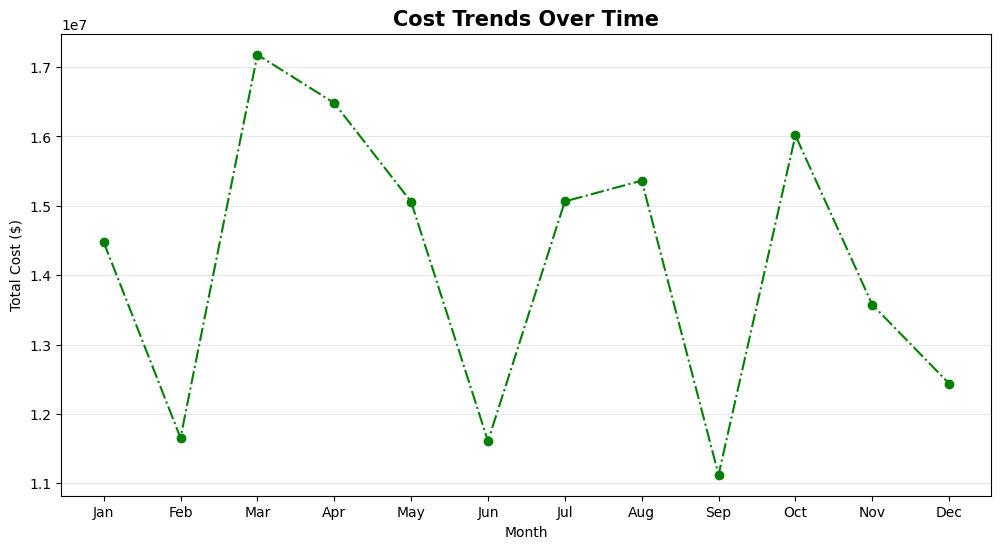

In [163]:
# Task 1: Create a Line Plot Showing Cost Trends Over Time
# Create a chart that shows how total_cost changes over order_month.
# Write code to:
# • Group by order_month and calculate sum of total_cost for each month
# • Create a line plot with order_month on x-axis and total cost on y-axis
# • Add a title: "Total Cost ($)"
# • Add x-axis label: "Month"
# • Add y-axis label: "Total Cost ($)"
# • Add a legend
# • Save the figure as "cost_trend.png"
# Answer this: Does cost increase or decrease over time? Are there patterns?   

month_order =['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)
monthly_cost = df.groupby('month')['total_cost'].sum()

plt.figure(figsize=(12,6))
plt.plot(monthly_cost.index, monthly_cost.values, 'g-.o')
plt.xlabel("Month")
plt.ylabel("Total Cost ($)")
plt.title("Cost Trends Over Time",fontweight='bold', fontsize=15)
plt.grid(True, alpha=0.3, axis='y')
plt.savefig("cost_trend.png")
plt.show()

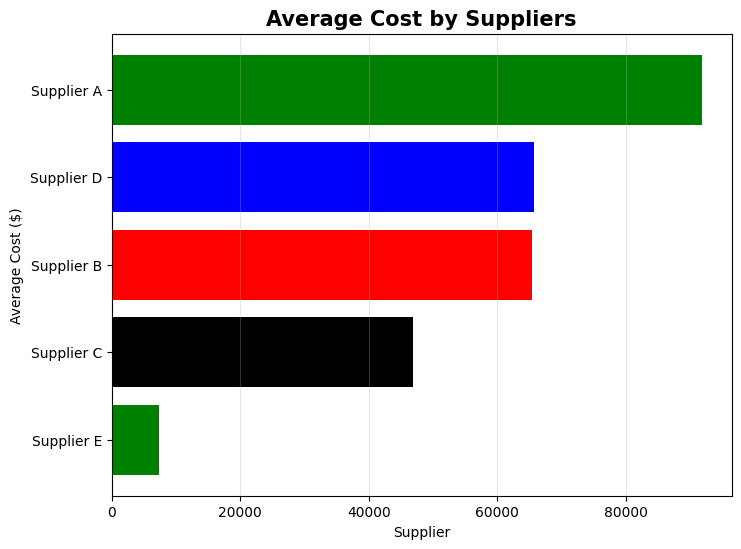

In [164]:
# Task 2: Create Bar Charts Comparing Suppliers
# Create a chart showing key metrics for each supplier.

# Create Chart 1: Average Cost by Supplier
# • Group by supplier_name, calculate mean total_cost
# • Create a bar chart with supplier_name on x-axis, avg cost on y-axis
# • Add title and labels
# • Add a color for each bar (use different colors)

avg_cost_supplier = df.groupby('supplier_name')['total_cost'].mean().sort_values(ascending=True)

plt.figure(figsize=(8,6))
plt.barh(avg_cost_supplier.index, avg_cost_supplier.values, color= ('green','black','red','blue'))
plt.xlabel("Supplier")
plt.ylabel("Average Cost ($)")
plt.title("Average Cost by Suppliers", fontweight='bold', fontsize=15)
plt.grid(True, alpha=0.3,axis='x')
plt.savefig("avg_cost_supplier.png")
plt.show()

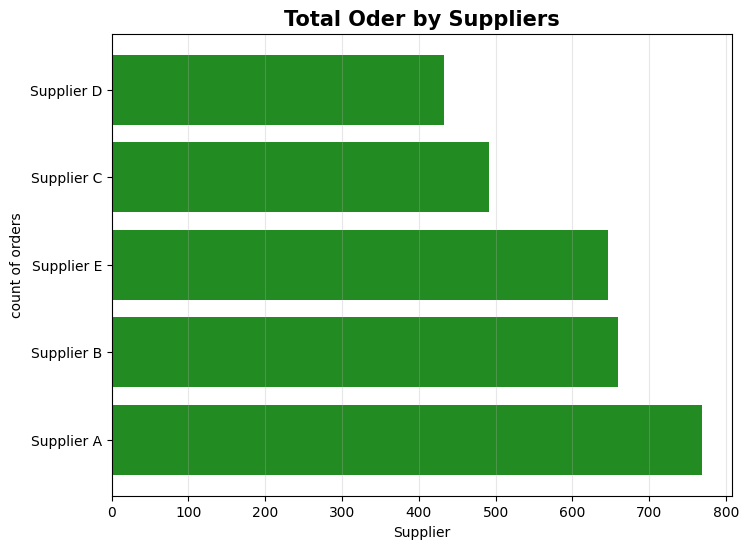

In [165]:
# Create Chart 2: Order Count by Supplier
# • Group by supplier_name, calculate count of orders
# • Create a bar chart with supplier_name on x-axis, order count on y-axis
# • Add title and labels
# Save both charts.
# Answer this: Which supplier is most expensive? Which has most orders?

Total_order = df.groupby('supplier_name')['order_id'].count().sort_values(ascending=False)

plt.figure(figsize=(8,6))
plt.barh(Total_order.index, Total_order.values, color= '#228B22')
plt.xlabel("Supplier")
plt.ylabel("count of orders")
plt.title("Total Oder by Suppliers",fontweight='bold', fontsize=15)
plt.grid(True, alpha=0.3,axis='x')
plt.savefig("total_order_supplier.png")
plt.show()

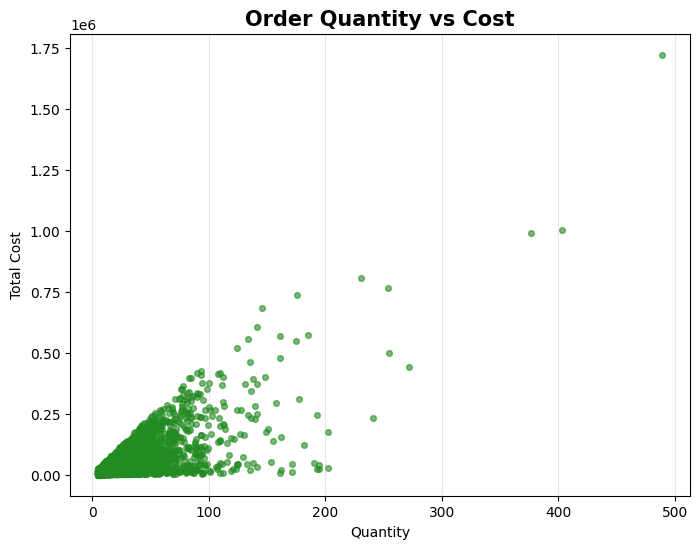

In [166]:
# Task 3: Create a Scatter Plot Showing Relationship Between Two Variables
# Create a chart showing the relationship between quantity and total_cost.
# Write code to:
# • Create a scatter plot with quantity on x-axis and total_cost on y-axis
# • Each point represents one order
# • Add title: "Order Quantity vs Cost"
# • Add x-axis label: "Quantity (units)"
# • Add y-axis label: "Cost ($)"
# • Add a legend
# • Save as "quantity_vs_cost.png"
# Answer this: Do larger orders cost more? Is the relationship linear or scattered? 



plt.figure(figsize=(8,6))
plt.scatter(df['quantity'],  df['total_cost'],alpha=0.6, s=17,color= '#228B22')
plt.xlabel("Quantity")
plt.ylabel("Total Cost")
plt.title("Order Quantity vs Cost",fontweight='bold', fontsize=15)
plt.grid(True, alpha=0.3,axis='x')
plt.savefig("Order Quantity vs Cost.png")
plt.show()

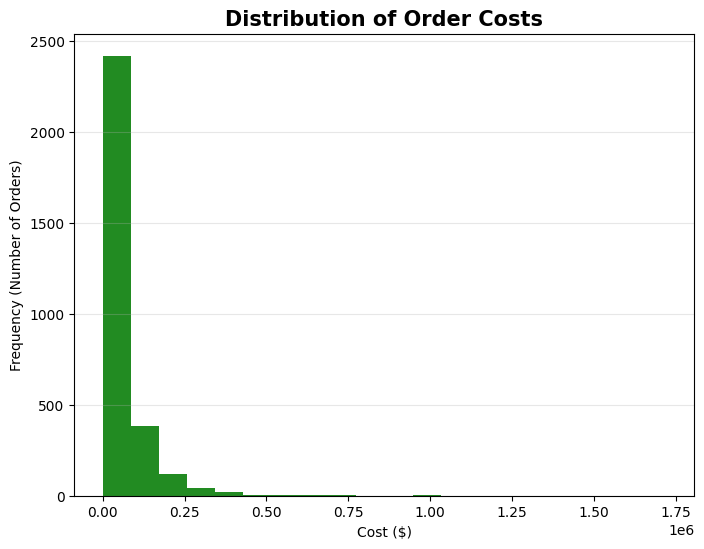

In [167]:
# Task 4: Create a Histogram Showing Distribution of a Variable
# Create a chart showing how order costs are distributed.
# Write code to:
# • Create a histogram of total_cost column
# • Use 20 bins (20 bars showing the distribution)
# • Add title: "Distribution of Order Costs"
# • Add x-axis label: "Cost ($)"
# • Add y-axis label: "Frequen
plt.figure(figsize=(8,6))
plt.hist(df['total_cost'], bins=20, color= '#228B22')
plt.xlabel("Cost ($)")
plt.ylabel("Frequency (Number of Orders)")
plt.title("Distribution of Order Costs",fontweight='bold', fontsize=15)
plt.grid(True, alpha=0.3,axis='y')
plt.savefig("cost_distribution.png")
plt.show()

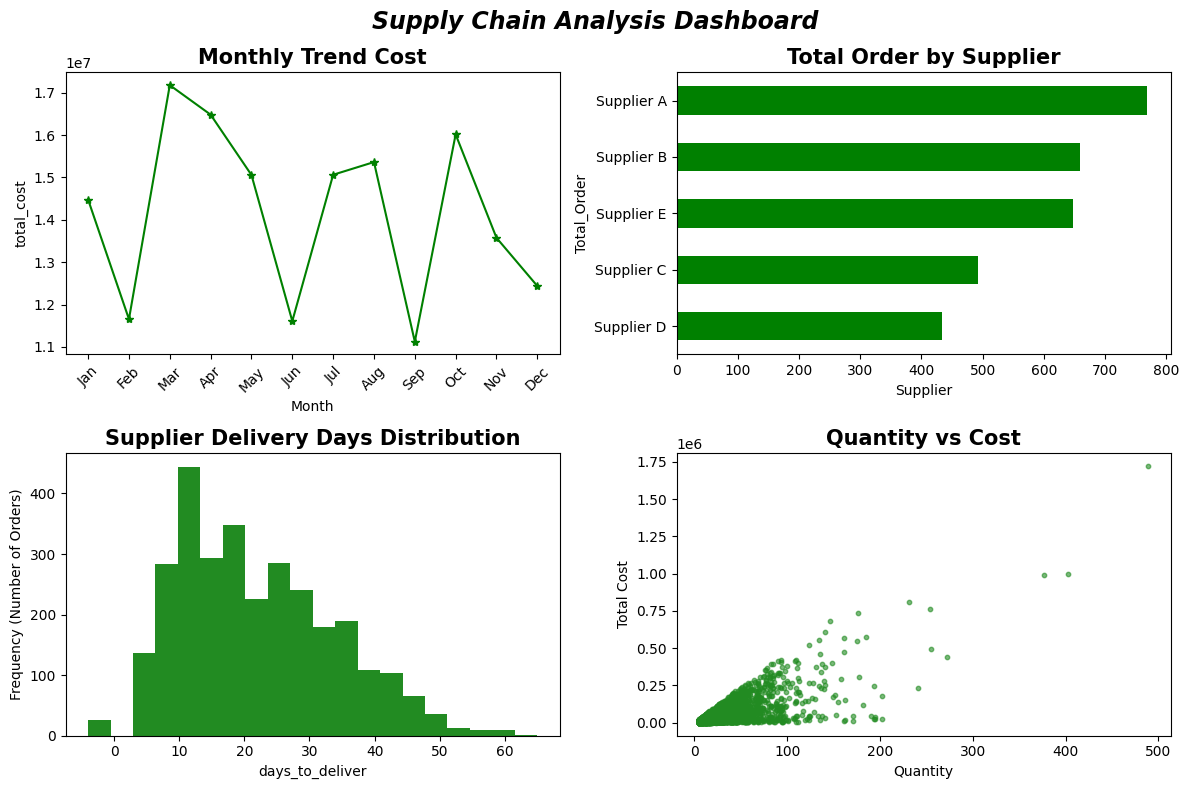

In [168]:
# Task 5: Create Multiple Plots on One Figure
# Create a figure with multiple subplots showing different aspects of the data.
# Write code to:
# • Create a figure with 2 rows and 2 columns (4 subplots total)
# • Subplot 1 (top left): Line plot of total cost by month
# • Subplot 2 (top right): Bar chart of order count by supplier
# • Subplot 3 (bottom left): Histogram of delivery days
# • Subplot 4 (bottom right): Scatter plot of quantity vs cost
# • Add a title to the entire figure: "Supply Chain Analysis Dashboard"
# • Make sure each subplot has its own title and labels
# • Adjust spacing so plots don't overlap
# • Save as "dashboard.png"
# This creates a professional dashboard showing multiple insights at once.

fig, axes = plt.subplots(2,2, figsize=(12,8))
fig.suptitle("Supply Chain Analysis Dashboard",fontweight='bold', fontsize=17, fontstyle='italic')
#Line plot of total cost by month
Total_Cost = df.groupby('month')['total_cost'].sum()
month_order =['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)
axes[0,0].plot(Total_Cost.index, Total_Cost.values, 'g-*')
axes[0,0].set_ylabel('total_cost')
axes[0,0].set_xlabel('Month')
axes[0,0].set_title('Monthly Trend Cost',fontweight='bold', fontsize=15)
axes[0,0].tick_params(axis='x', rotation=45)


#Bar chart of order count by supplier
Total_order_supplier = df.groupby('supplier_name')['order_id'].count().sort_values(ascending=True)
Total_order_supplier.plot(kind='barh',ax=axes[0,1], color='g')
axes[0,1].set_ylabel('Total_Order')
axes[0,1].set_xlabel('Supplier')
axes[0,1].set_title('Total Order by Supplier',fontweight='bold', fontsize=15,)

#Histogram of delivery days
axes[1,0].hist(df['days_to_deliver'], bins=20, color= '#228B22')
axes[1,0].set_ylabel('Frequency (Number of Orders)')
axes[1,0].set_xlabel('days_to_deliver')
axes[1,0].set_title('Supplier Delivery Days Distribution',fontweight='bold', fontsize=15,)

#Scatter plot of quantity vs cost
axes[1,1].scatter(df['quantity'], df['total_cost'], alpha=0.6, s=10,color= '#228B22')
axes[1,1].set_ylabel('Total Cost')
axes[1,1].set_xlabel('Quantity')
axes[1,1].set_title('Quantity vs Cost',fontweight='bold', fontsize=15,)

plt.tight_layout()
plt.savefig("dashboard.png")
plt.show()

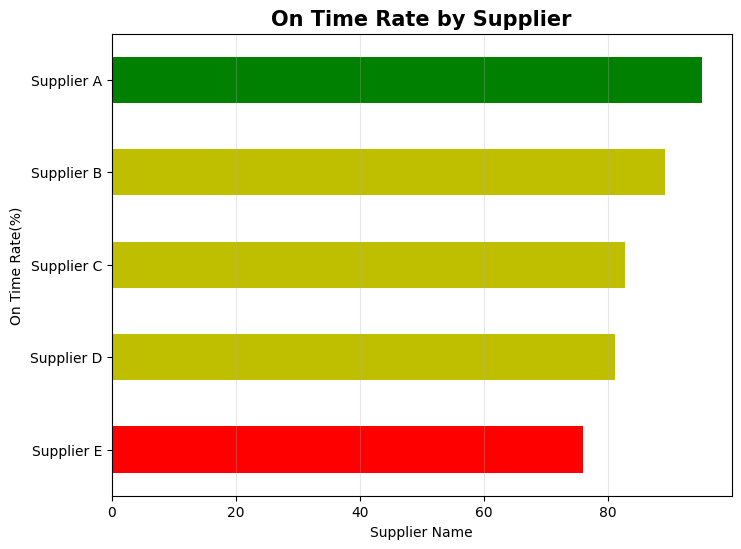

In [169]:
# Create a bar chart showing on_time_rate for each supplier. Color the bars: green for 
# suppliers with >90% on-time rate, yellow for 80-90%, red for <80%. This makes good and bad performers obvious at a glance.

on_time_rate = (df.groupby('supplier_name')['On Time'].mean()*100).sort_values(ascending=True)
plt.figure(figsize=(8,6))
colors =[]
for rate in on_time_rate:
    if rate >=90:
        colors.append('g')
    elif rate >=80:
        colors.append('y')
    else :
        colors.append('r')
on_time_rate.plot(kind='barh',color=colors)
plt.xlabel("Supplier Name")
plt.ylabel("On Time Rate(%)")
plt.title("On Time Rate by Supplier",fontweight='bold', fontsize=15)
plt.grid(True, alpha=0.3, axis='x')
plt.savefig("on_time_rate_supplier.png")
plt.show()        

<Figure size 1400x1000 with 0 Axes>

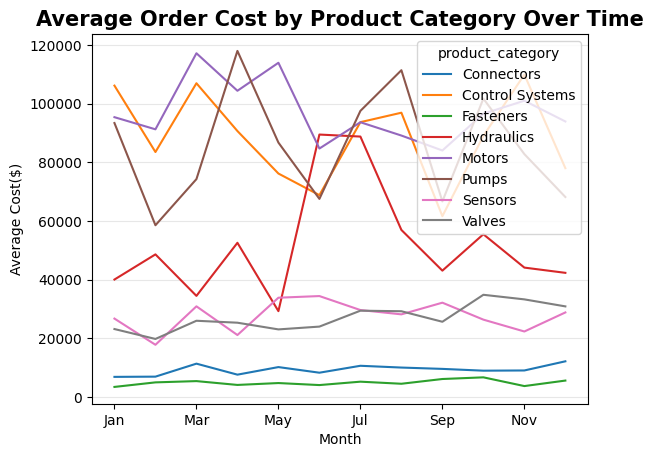

In [170]:
# Create a line plot showing average order cost for each product_category over time (by 
# month). Use different colors for different categories. Which products' costs are stable? 
# Which are volatile

plt.figure(figsize=(14,10))
monthly_cost = df.pivot_table(index='month', columns='product_category',values='total_cost',aggfunc='mean')
monthly_cost.plot()
plt.xlabel("Month")
plt.ylabel("Average Cost($)")
plt.title("Average Order Cost by Product Category Over Time",fontweight='bold', fontsize=15)
plt.grid(True, alpha=0.3,axis='y')
plt.savefig("avg_cost_category_time.png")
plt.show()


In [171]:
# ADVANCED VISUALIZATION with SEABORN
import seaborn as sns

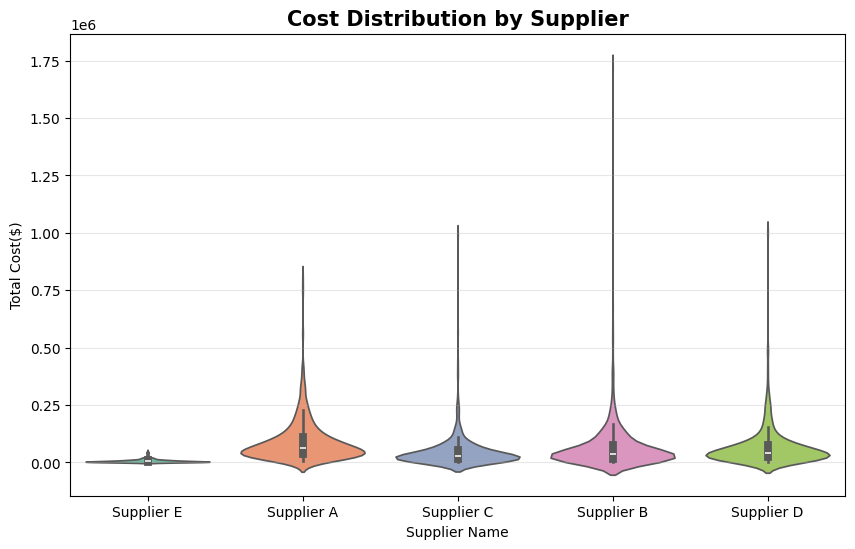

In [172]:
# Task 1: Create Violin Plots Comparing Distributions by Group
# Create visualizations showing how distributions differ across suppliers.
# Write code to:
# • Create a violin plot with supplier_name on x-axis and total_cost on y-axis
# • This shows the full distribution of costs for each supplier
# • Add title: "Cost Distribution by Supplier"
# • Color each supplier differently
# • Add a box plot inside the violins to show quartiles
# • Save as "cost_by_supplier_violin.png"

plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='supplier_name',y='total_cost',  inner='box', palette='Set2' )
plt.xlabel("Supplier Name")
plt.ylabel("Total Cost($)")
plt.title("Cost Distribution by Supplier",fontweight='bold', fontsize=15)
plt.grid(True, alpha=0.3,axis='y')
plt.savefig("cost_by_supplier_violin.png")
plt.show()

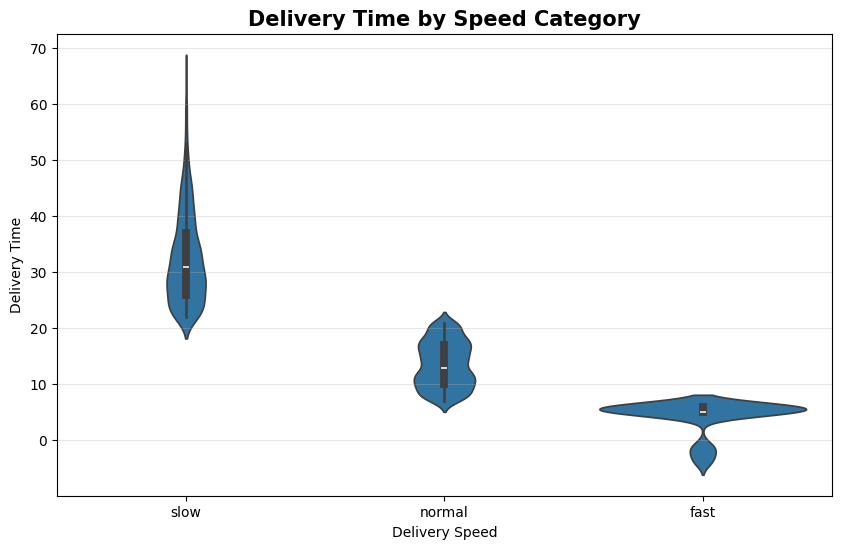

In [173]:
# Create another violin plot showing delivery_speed_category on x-axis and days_to_deliver
# on y-axis to compare delivery times across speed categories.
# Answer this: Which supplier has the widest range of costs? Which has the most consistent pricing

plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='Delivery_Speed_Category',y='days_to_deliver')
plt.xlabel("Delivery Speed")
plt.ylabel("Delivery Time")
plt.title("Delivery Time by Speed Category",fontweight='bold', fontsize=15)
plt.grid(True, alpha=0.3,axis='y')
plt.savefig("delivery_time_speed_violin.png")
plt.show()

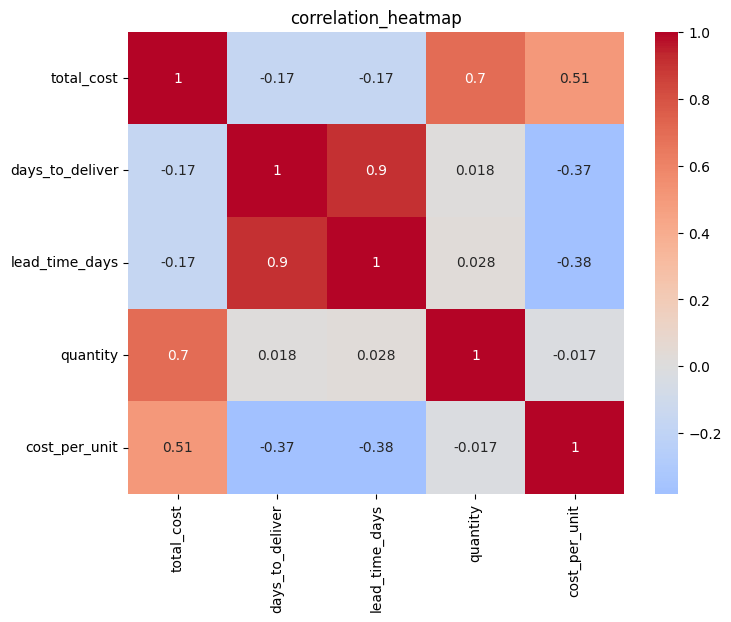

In [174]:
# Task 2: Create Heatmaps Showing Correlations
# Create a heatmap showing which variables correlate with each other.
# Write code to:
# • Select numeric columns: total_cost, quantity, lead_time_days, days_to_deliver, cost_per_unit
# • Calculate the correlation matrix between these columns
# • Create a heatmap showing correlations with color intensity
# • Add a color bar showing the scale
# • Annotate cells with correlation values
# • Use a diverging color palette (e.g., blue=negative, white=zero, red=positive)
# • Save as "correlation_heatmap.png"
# Answer this: Which variables are strongly related? Which are independent? Are there any 
# surprising correlations?

numeric_col = ['total_cost','days_to_deliver','lead_time_days','quantity','cost_per_unit']
column_df = df[numeric_col].corr()
plt.figure(figsize=(8,6))
sns.heatmap(column_df, annot=True, cmap='coolwarm', center=0)
plt.title('correlation_heatmap')
plt.savefig('correlation_heatmap.png')
plt.show()

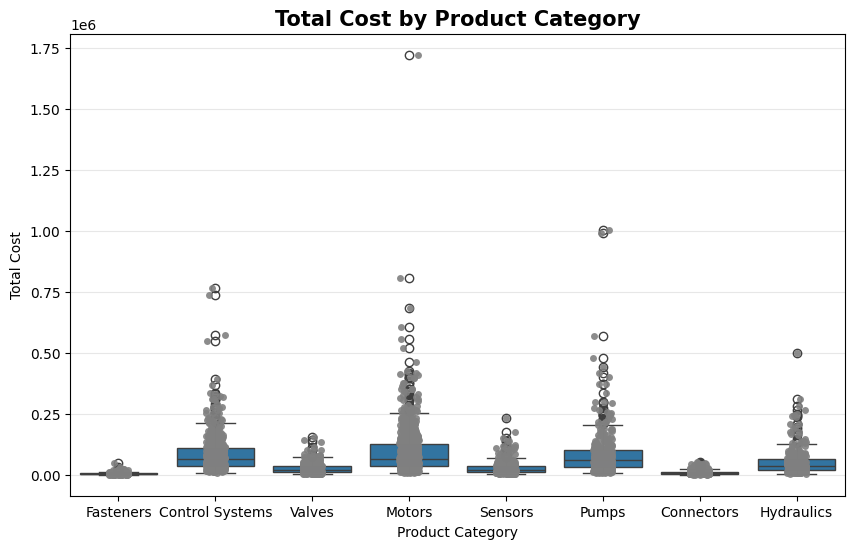

In [175]:
# Task 3: Create Box Plots and Swarm Plots for Categorical Comparison
# Create visualizations comparing metrics across categories.
# Create Chart 1: Box plot of total_cost by product_category
# • Shows the distribution of costs for each product type
# • Overlay a swarm plot to show individual points
# • This reveals both the pattern and the outliers

plt.figure(figsize=(10,6))
sns.boxplot(data=df, y='total_cost',x='product_category')
sns.stripplot(data=df, y='total_cost',x='product_category', color='grey', alpha=0.9)
plt.xlabel("Product Category")
plt.ylabel("Total Cost")
plt.title("Total Cost by Product Category",fontweight='bold', fontsize=15)
plt.grid(True, alpha=0.3,axis='y')
plt.savefig("product_cost_box.png")
plt.show()

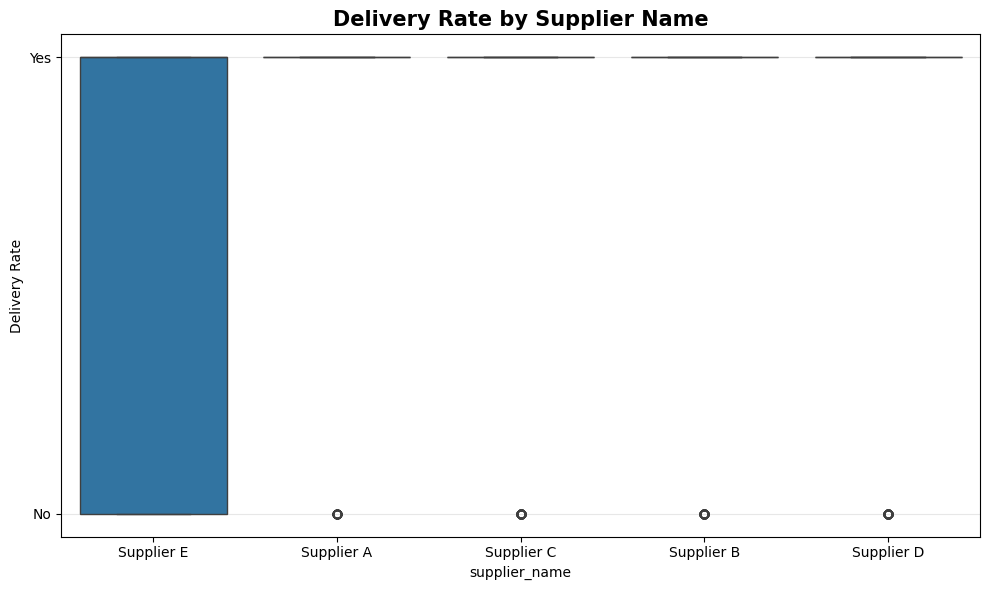

In [176]:
# Create Chart 2: Box plot of on_time by supplier_name
# • Shows on-time delivery performance for each supplier
# • Make it easy to see which suppliers are most reliable
# Save both charts.
# Answer this: Which product categories are most expensive? Which suppliers are most  reliable?

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='supplier_name',y='on_time',)
plt.xlabel("supplier_name")
plt.ylabel("Delivery Rate")
plt.title("Delivery Rate by Supplier Name",fontweight='bold', fontsize=15)
plt.grid(True, alpha=0.3,axis='y')
plt.tight_layout()
plt.savefig("supplier_delivery_rate-box.png")
plt.show()

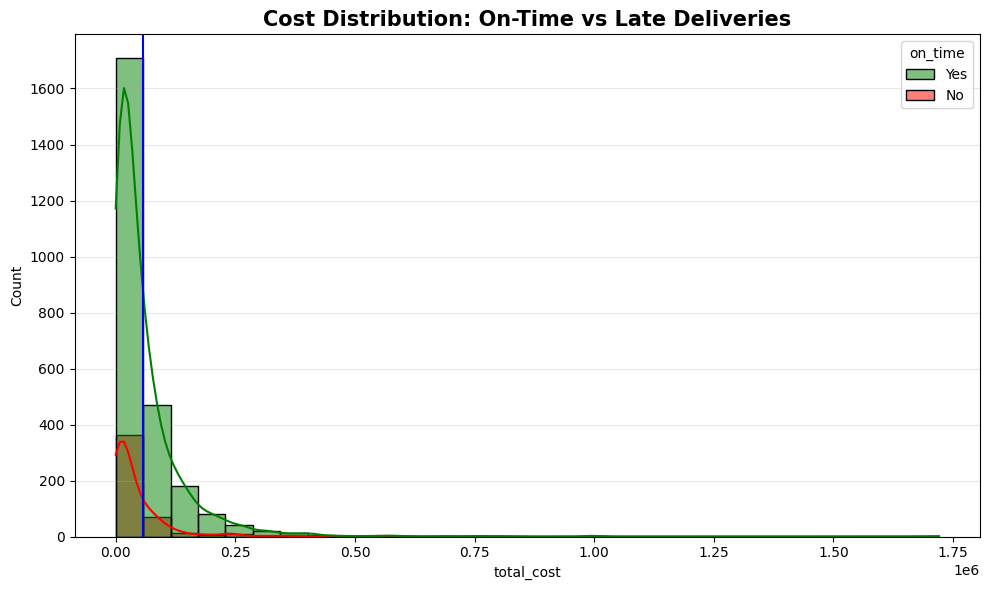

In [177]:
# Task 4: Create KDE Plots for Smooth Distributions
# Create smooth distribution visualizations showing patterns.
# Write code to:
# • Create a KDE plot of total_cost for all orders
# • Add a histogram underneath with transparency to show the actual data
# • Add a vertical line showing the mean cost
# • Color by on_time status (on-time vs late orders) to compare distributions
# • Title: "Cost Distribution: On-Time vs Late Deliveries"
# • Save as "cost_kde_by_status.png"

plt.figure(figsize=(10,6))
sns.histplot(data=df, x='total_cost', hue='on_time',kde=True, bins=30, palette=['green','red'])
plt.axvline(df['total_cost'].mean(), color='blue', label='Mean Cost')
plt.title("Cost Distribution: On-Time vs Late Deliveries",fontweight='bold', fontsize=15)
plt.grid(True, alpha=0.3,axis='y')
plt.tight_layout()
plt.savefig("cost_kde_by_status.png")
plt.show()

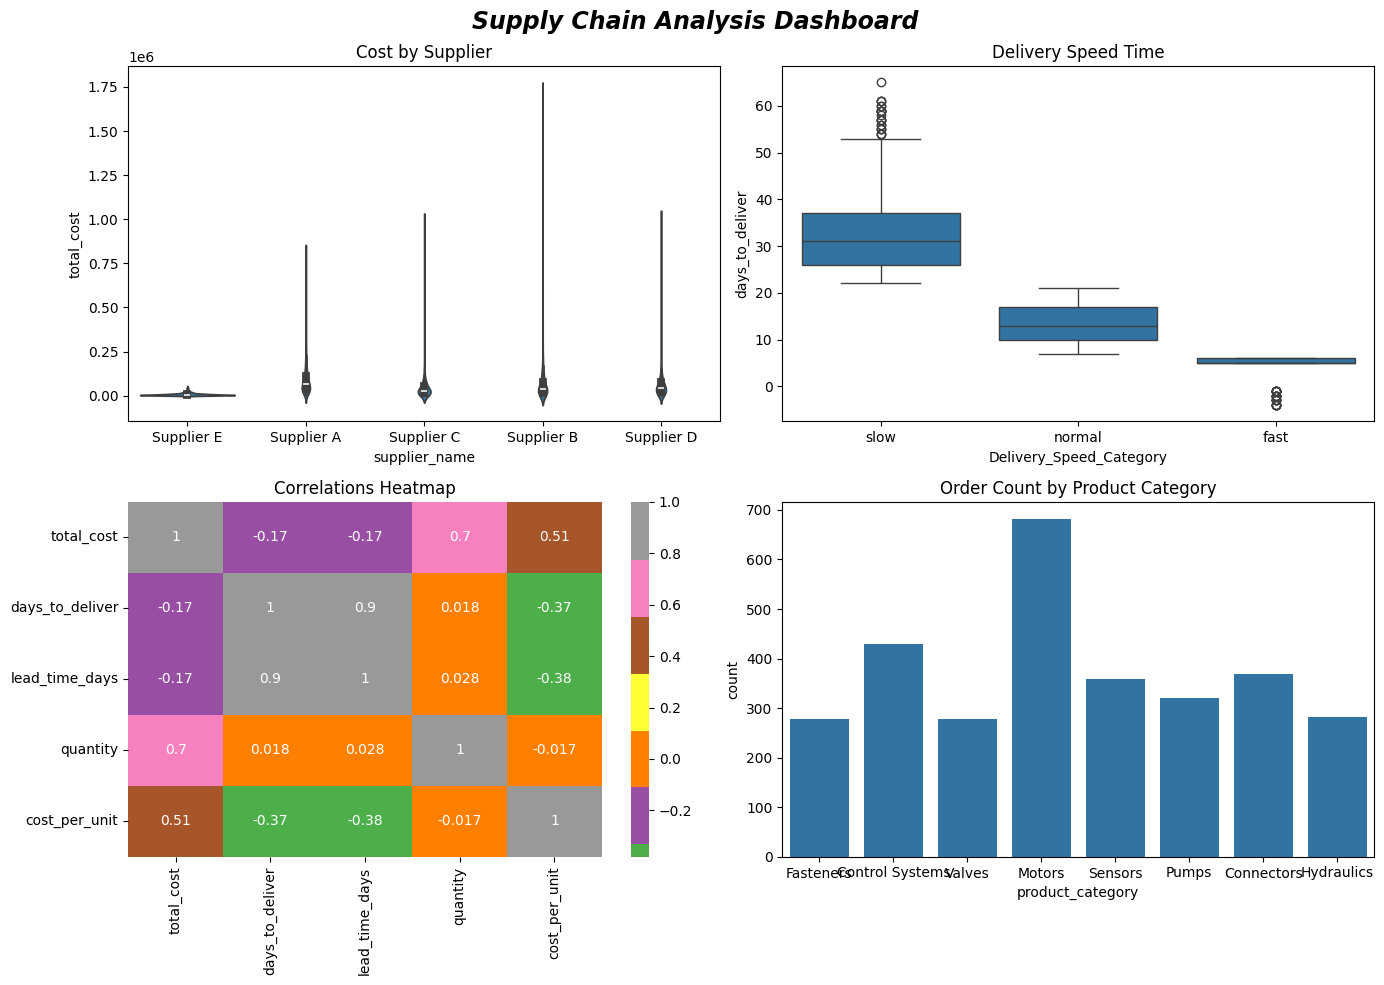

In [178]:
# Task 5: Create a Comprehensive Multi-Panel Seaborn Dashboard
# Create a figure with multiple Seaborn plots showing different aspects.
# Write code to:
# • Create a 2x2 figure with four subplots
# • Subplot 1 (top left): Violin plot of total_cost by supplier_name
# • Subplot 2 (top right): Box plot of days_to_deliver by delivery_speed_category
# • Subplot 3 (bottom left): Heatmap of correlations between numeric variables
# • Subplot 4 (bottom right): Count plot showing order count by product_category
# • Add an overall title: "Supply Chain Analysis Dashboard"
# • Use consistent color palette across all plots
# • Make sure all axes are labeled clearly
# • Save as "seaborn_dashboard.png"
# This creates a professional multi-dimensional view of your supply chain.

fig, axes = plt.subplots(2,2, figsize=(14,10))
fig.suptitle("Supply Chain Analysis Dashboard",fontweight='bold', fontsize=17, fontstyle='italic')

#Violin plot of total_cost by supplier_name
sns.violinplot(data=df, x='supplier_name', y='total_cost', ax=axes[0,0])
axes[0,0].set_title('Cost by Supplier')

##Box plot of days_to_deliver by delivery_speed_category
sns.boxplot(data=df, x='Delivery_Speed_Category', y='days_to_deliver', ax=axes[0,1])
axes[0,1].set_title('Delivery Speed Time')

#Heatmap of correlations between numeric variables
sns.heatmap(column_df, annot=True, cmap='Set1', center=0, ax=axes[1,0])
axes[1,0].set_title('Correlations Heatmap')

#Count plot showing order count by product_category
sns.countplot(data=df, x='product_category', ax=axes[1,1])
axes[1,1].set_title('Order Count by Product Category')

plt.tight_layout()
plt.savefig("seaborn_dashboard.png")
plt.show()

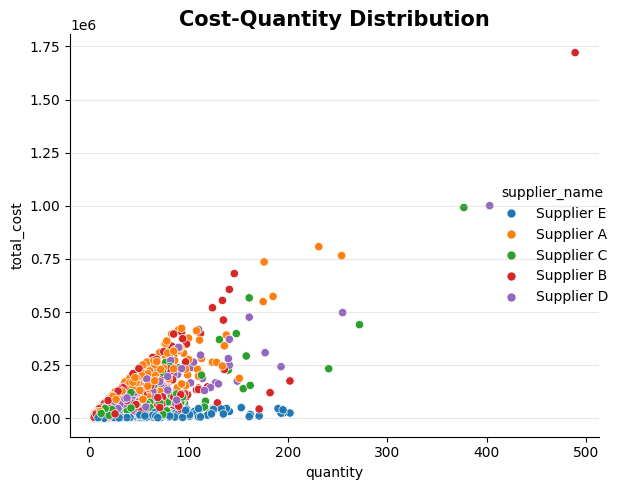

In [179]:
# Task 6
# Create a relplot showing the relationship between quantity and total_cost, colored by 
# supplier_name. This combines supplier comparison with cost-quantity relationship in one 
# chart. Which supplier's orders cluster at different price points?

sns.relplot(data=df, x='quantity', y='total_cost', hue='supplier_name')
plt.title("Cost-Quantity Distribution",fontweight='bold', fontsize=15)
plt.grid(True, alpha=0.3,axis='y')
plt.tight_layout()
plt.savefig("cost-quantity relationship.png")
plt.show()

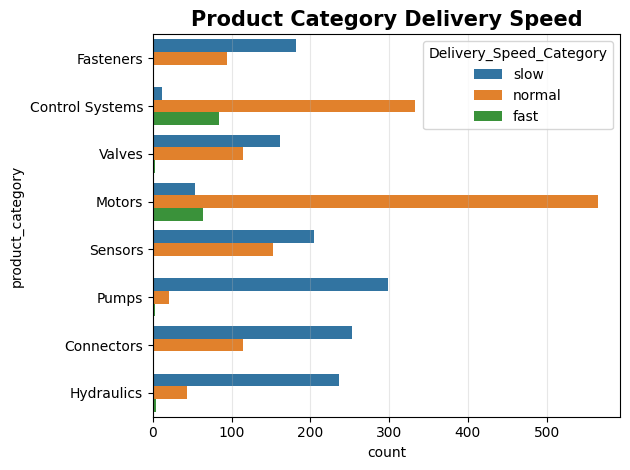

In [180]:
# Task 7
# Create a count plot showing the number of orders by product_category, colored by  delivery_speed_category.
#  Which product categories have the most “fast” deliveries? Which  have the most “slow” deliveries?

sns.countplot(data=df, y='product_category', hue='Delivery_Speed_Category')
plt.title("Product Category Delivery Speed",fontweight='bold', fontsize=15)
plt.grid(True, alpha=0.3,axis='x')
plt.tight_layout()
plt.savefig("product_category_delivery_speed.png")
plt.show()

In [181]:
# Exploratory Data Analysis

import warnings
warnings.filterwarnings('ignore')

Statistics for Total Cost
mean = 56,679.37
median = 30,911.19
std dev = 83,565.24
max = 1,720,595.40
min = -207.32
25th percentile = 11,236.39
75th percentile = 70,688.51


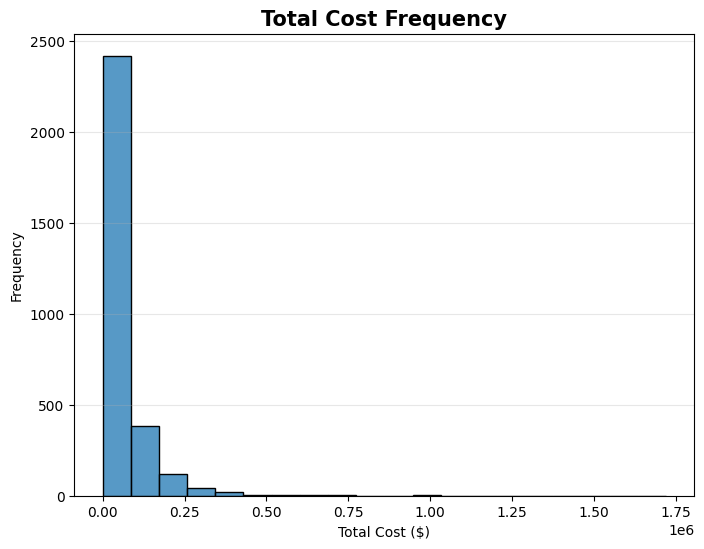

In [182]:
# Task 1: Univariate Analysis of Key Metrics
# Analyze each important variable independently.
# For total_cost column:
# • Calculate mean, median, std dev, min, max, 25th percentile, 75th percentile
# • Create a histogram showing distribution

col1 = 'total_cost'
mean_cost = df[col1].mean()
median_cost = df[col1].median()
std_cost = df[col1].std()
min_cost = df[col1].min()
max_cost = df[col1].max()
q25_cost = df[col1].quantile(0.25)
q75_cost = df[col1].quantile(0.75)

print("Statistics for Total Cost")
print(f"mean = {mean_cost:,.2f}")
print(f"median = {median_cost:,.2f}")
print(f"std dev = {std_cost:,.2f}")
print(f"max = {max_cost:,.2f}")
print(f"min = {min_cost:,.2f}")
print(f"25th percentile = {q25_cost:,.2f}")
print(f"75th percentile = {q75_cost:,.2f}")

plt.figure(figsize=(8,6))
sns.histplot(data=df, x='total_cost',bins= 20)
plt.ylabel("Frequency")
plt.xlabel("Total Cost ($)")
plt.title("Total Cost Frequency",fontweight='bold', fontsize=15)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

In [183]:
# • Describe the distribution shape. Is it normal, skewed, or multimodal?
        # Answer: "The total cost chart is right skewed because most orders are cheap while few are really expensive"

Summary Statistics for Quantity
mean_qty = 32.63
median_qty = 24.00
std.dev_qty = 31.37
min_qty = 5.00
max_qty = 489.00
q25_qty = 14.00
q75_qty = 41.00


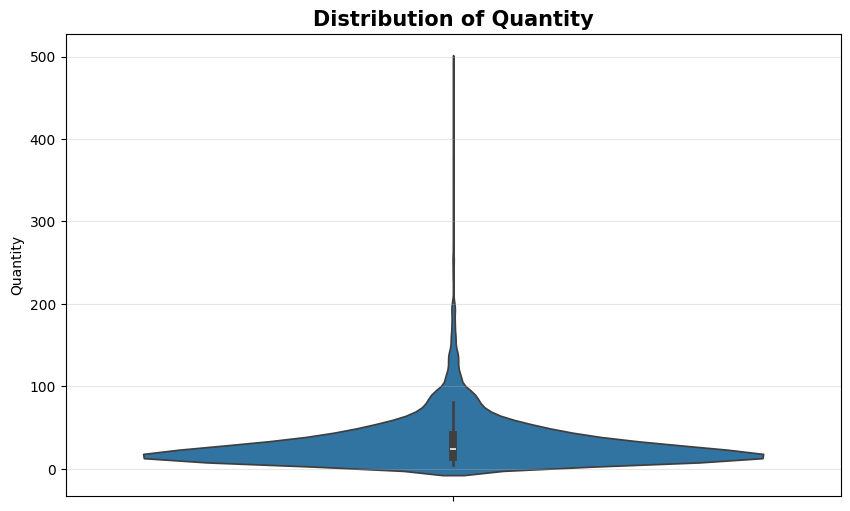

Most Common Order Size= 5.00  occurred 125 times


In [184]:
# For quantity column:
# • Calculate mean, median, std dev, min, max, 25th percentile, 75th percentile

qty = df['quantity']
stats = {
'mean_qty':qty.mean(),
'median_qty':qty.median(),
'std.dev_qty':qty.std(),
'min_qty':qty.min(),
'max_qty':qty.max(),
'q25_qty':qty.quantile(0.25),
'q75_qty':qty.quantile(0.75)
}

print("Summary Statistics for Quantity")
for k, v in stats.items():
    print(f"{k} = {v:,.2f}")

# • Create a violin plot showing distribution           
plt.figure(figsize=(10,6))
sns.violinplot(data=df, y=df['quantity'])
plt.ylabel("Quantity")
plt.title("Distribution of Quantity",fontweight='bold', fontsize=15)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

# • Identify the most common order size range
mode_qty = qty.mode()[0]
mode_count = (qty ==  mode_qty).sum()
print(f"Most Common Order Size= {mode_qty:,.2f}  occurred {mode_count} times")


Summary Statistics for Quantity
mean_lead_time = 20.42
median_lead_time = 18.00
std.dev_lead_time = 10.22
min_lead_time = 5.00
max_lead_time = 53.00
q25_lead_time = 12.00
q75_lead_time = 28.00


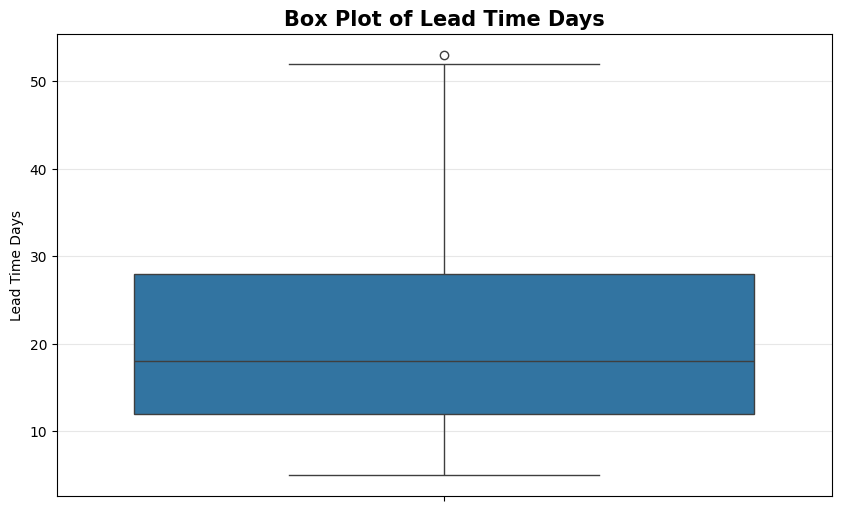

[53, 52, 52]


In [185]:
# For lead_time_days column:
# • Calculate statistics

lead = df['lead_time_days']
stats = {
'mean_lead_time':lead.mean(),
'median_lead_time':lead.median(),
'std.dev_lead_time':lead.std(),
'min_lead_time':lead.min(),
'max_lead_time':lead.max(),
'q25_lead_time':lead.quantile(0.25),
'q75_lead_time':lead.quantile(0.75)
}

print("Summary Statistics for Quantity")
for k, v in stats.items():
    print(f"{k} = {v:,.2f}")

# • Create a box plot showing distribution           
plt.figure(figsize=(10,6))
sns.boxplot(data=df, y= lead)
plt.ylabel("Lead Time Days")
plt.title("Box Plot of Lead Time Days",fontweight='bold', fontsize=15)
plt.grid(True, alpha=0.3, axis='y')
plt.show()


# • Identify if any lead times are outliers (more than 3 standard deviations from mean)
avg = df['lead_time_days'].mean()
std = df['lead_time_days'].std()
 
outliers = df[abs(df['lead_time_days']-avg)>3*std]

print(outliers['lead_time_days'].tolist())

=== Summary Statistics for Quantity===
mean = 21.93
median = 20.00
std.dev = 11.90
min = -4.00
max = 65.00
q25 = 12.00
q75 = 30.00


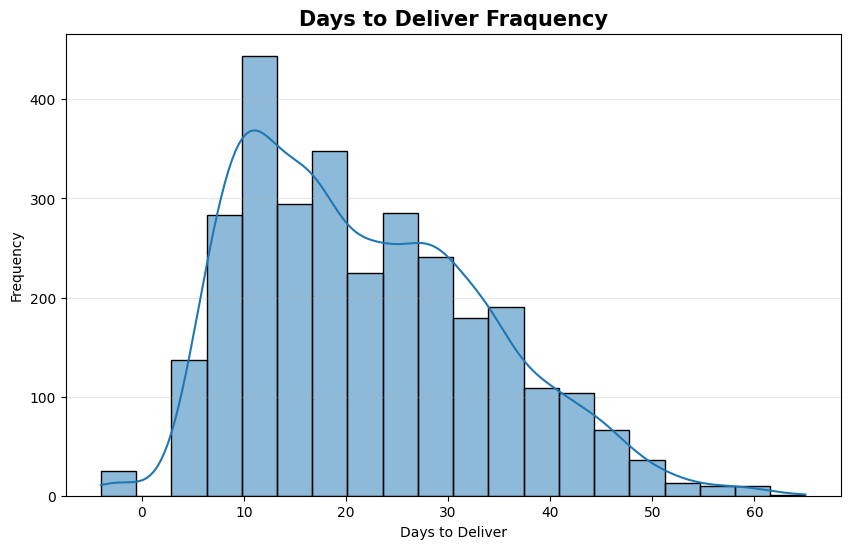

On Time = 86.0%
Average Delay = 2.0days
Yes, usually matches expected time


In [186]:
# For days_to_deliver column:
# • Calculate statistics
# • Create a histogram and KDE plot overlay

delivery_time = df['days_to_deliver']
stats = {
'mean':delivery_time.mean(),
'median':delivery_time.median(),
'std.dev':delivery_time.std(),
'min':delivery_time.min(),
'max':delivery_time.max(),
'q25':delivery_time.quantile(0.25),
'q75':delivery_time.quantile(0.75)
}

print("=== Summary Statistics for Quantity===")
for k, v in stats.items():
    print(f"{k} = {v:,.2f}")

# • Create a histogram and KDE plot overlay           
plt.figure(figsize=(10,6))
sns.histplot(df['days_to_deliver'], kde= True, bins=20)
plt.xlabel("Days to Deliver")
plt.ylabel("Frequency")
plt.title("Days to Deliver Fraquency",fontweight='bold', fontsize=15)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

# • Compare to lead_time_days. Do deliveries usually match expected times?

delay = df['days_to_deliver'] - df['lead_time_days']

on_time_percent = round((delay <=0).mean()*100)
avg_delay_days = round(delay.mean())
print(f"On Time = {on_time_percent:.1f}%")
print(f"Average Delay = {avg_delay_days:.1f}days")

if on_time_percent >=50:
    print("Yes, usually matches expected time")
else:
    print("No, usually late")

On Time Order = 2570
Late Order = 430
On Time Percentage = 86.0%
Late Order  Percentage = 14.0%


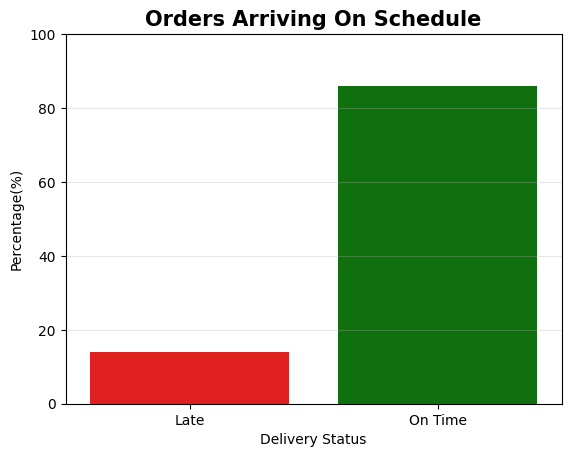

In [187]:
# For on_time column:
# • Calculate count and percentage of on-time vs late orders
# • What percentage of orders arrive on schedule?
# Document your findings for each variable in plain language.

count = df['On Time'].value_counts()
percentage = round(df['On Time'].value_counts(normalize=True)*100)
print(f"On Time Order = {count[1]}")
print(f"Late Order = {count[0]}")
print(f"On Time Percentage = {percentage[1]:.1f}%")
print(f"Late Order  Percentage = {percentage[0]:.1f}%")

# • Create a bar chart
sns.barplot(x =['Late','On Time'], y =[percentage[0],  percentage[1]], legend=False,  palette =('r', 'g',))
plt.ylim(0,100)
plt.xlabel("Delivery Status")
plt.ylabel("Percentage(%)")
plt.title("Orders Arriving On Schedule",fontweight='bold', fontsize=15)
plt.grid(True, alpha=0.3, axis='y')
plt.show()


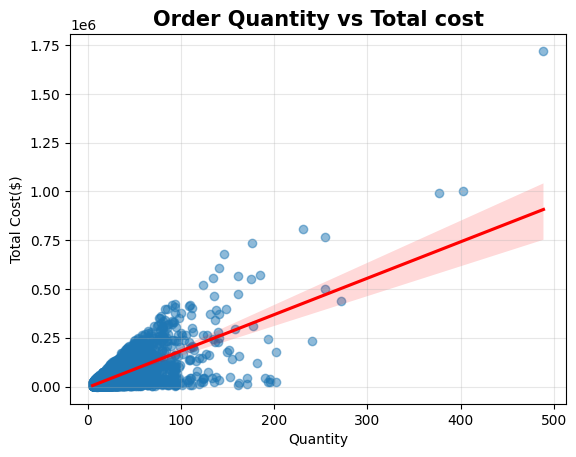

AVG Unit Price = $1758.31
AVG Price for Small Order = $1807.58
AVG Price for Large Order = $1716.75
Proportional


In [188]:
# Task 2: Bivariate Analysis - Relationships Between Variables. Analyze how variables relate to each other.
# Analyze quantity vs total_cost:
from scipy import stats
# • Create a scatter plot
# • Fit a trend line
sns.regplot(data=df, x='quantity', y='total_cost',
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.xlabel("Quantity")
plt.ylabel("Total Cost($)")
plt.title("Order Quantity vs Total cost",fontweight='bold', fontsize=15)
plt.grid(True, alpha=0.3)
plt.show()

#• Calculate correlation coefficient
column_corr = ['total_cost', 'quantity']
cor_matrix = df[column_corr].corr()
cor_matrix

#• Question: Do larger orders always cost more proportionally?
        #check if cost is propottional
df['unit_price'] =df['total_cost']/df['quantity']
avg_unit_cost = df['unit_price'].mean()
print(f"AVG Unit Price = ${avg_unit_cost:.2f}")

       # compare small vs large orders
small_order = df[df['quantity']<=14]['unit_price'].mean() #bottom 25%
large_order = df[df['quantity']>=41]['unit_price'].mean() #top 25%
print(f"AVG Price for Small Order = ${small_order:.2f}")
print(f"AVG Price for Large Order = ${large_order:.2f}")

       # does large oders cost most proportionally?
diff_in_order = abs(large_order-small_order)/avg_unit_cost
print("Proportional" if diff_in_order <0.1 else "Not Proportional")




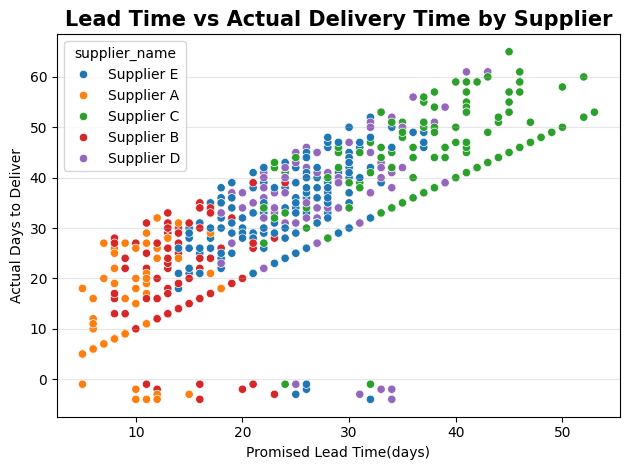

On-time delivery rate = 85.7%
Average delay when late = 11.8 days
               Avg Delay Days  Order Count
supplier_name                             
Supplier A                  0          769
Supplier B                  1          659
Supplier C                  2          492
Supplier D                  2          433
Supplier E                  3          647


In [189]:
# Analyze lead_time_days vs days_to_deliver:
# • Create a scatter plot colored by supplier_name

sns.scatterplot(data=df, x='lead_time_days', y='days_to_deliver', hue='supplier_name')
plt.title("Lead Time vs Actual Delivery Time by Supplier",fontweight='bold', fontsize=15)
plt.xlabel("Promised Lead Time(days)")
plt.ylabel("Actual Days to Deliver")
plt.grid(True, alpha=0.3,axis='y')
plt.tight_layout()
plt.show()

# • Question: Do suppliers with long lead times consistently deliver on time?

        #calculate on time metrics
df['delivery_diff'] = df['days_to_deliver'] - df['lead_time_days']
on_time_percentage =(df['delivery_diff']<=0).mean()*100
avg_delay =df[df['delivery_diff']>0] ['delivery_diff'].mean()

print(f"On-time delivery rate = {on_time_percentage:.1f}%")
print(f"Average delay when late = {avg_delay:.1f} days")

       # check by supllier name
supplier = df.groupby('supplier_name')['delivery_diff'].agg(['mean', 'count'])
supplier.columns = ['Avg Delay Days', 'Order Count']
supplier['Avg Delay Days'] = supplier['Avg Delay Days'].round(0).astype(int)
print(supplier.sort_values('Avg Delay Days'))

               on_time_rate
supplier_name              
Supplier A               95
Supplier B               89
Supplier C               83
Supplier D               81
Supplier E               76


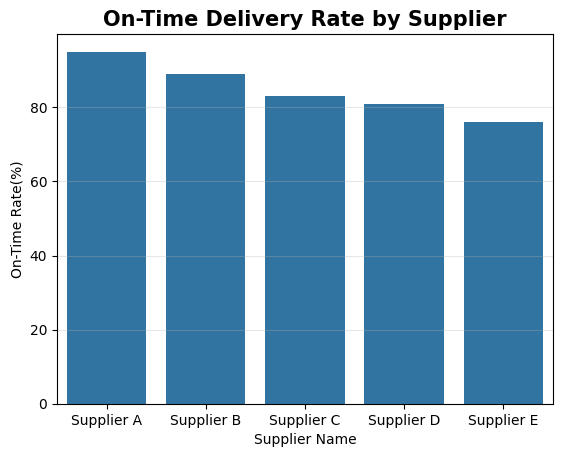

p-value =0.0000
Yes, supplier affects realiablity


In [190]:
# Analyze supplier_name vs on_time_rate:
# • Create a bar chart showing on-time percentage by supplier

supplier_on_time_rate = df.groupby('supplier_name')['On Time'].mean().mul(100).round(0).astype(int)
supplier_on_time_rate = supplier_on_time_rate.reset_index()
supplier_on_time_rate.columns = ['supplier_name','on_time_rate']
supplier_on_time_rate = supplier_on_time_rate.sort_values('on_time_rate', ascending=False)
print(supplier_on_time_rate.set_index('supplier_name'))

sns.barplot(data = supplier_on_time_rate, x ='supplier_name', y ='on_time_rate', order= supplier_on_time_rate['supplier_name'])
plt.xlabel("Supplier Name")
plt.ylabel("On-Time Rate(%)")
plt.title("On-Time Delivery Rate by Supplier",fontweight='bold', fontsize=15)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

# • Calculate correlation between supplier and reliability

from scipy.stats import chi2_contingency    
table = pd.crosstab(df['supplier_name'],df['On Time'])
chi2, p_value, _,_ = chi2_contingency(table)
print(f"p-value ={p_value:.4f}")
if p_value < 0.05:
    print("Yes, supplier affects realiablity")
else:
    print("No, supplier doesn't affects realiablity")

# • Question: Which supplier has the highest on-time delivery rate?

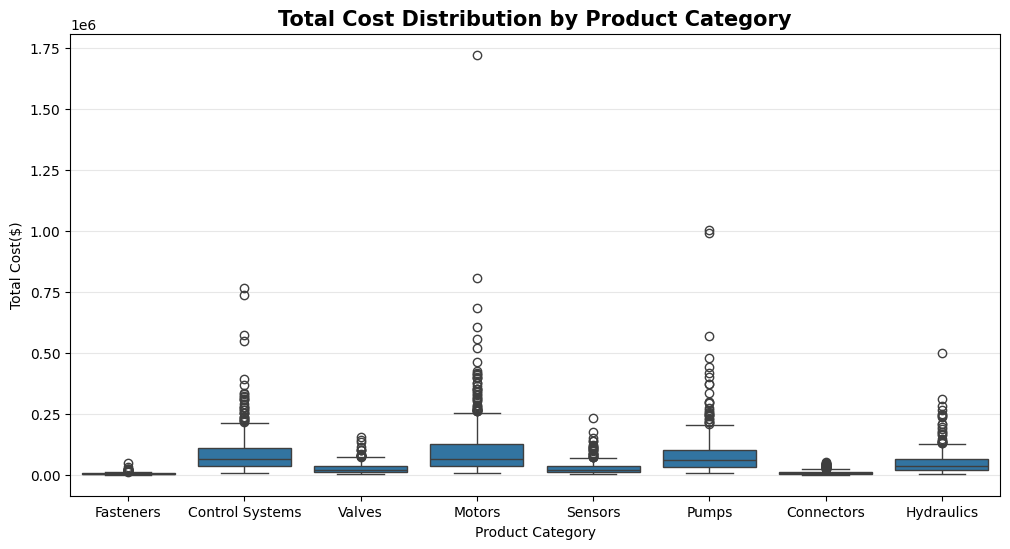

,Product Category,Revenue
0,Motors,66671196.0
1,Control Systems,38261291.0
2,Pumps,28021380.0


In [191]:
# Analyze product_category vs total_cost:
# • Create a box plot

plt.figure(figsize=(12,6))
sns.boxplot(data=df, x = 'product_category', y = 'total_cost')
plt.xlabel("Product Category")
plt.ylabel("Total Cost($)")
plt.title("Total Cost Distribution by Product Category",fontweight='bold', fontsize=15)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

# • Question: What product categories cost the most (top 3)?

top3 = df.groupby('product_category')['total_cost'].sum().sort_values(ascending=False).head(3).reset_index()
top3.columns = ['Product Category', 'Revenue']
top3.round(0)

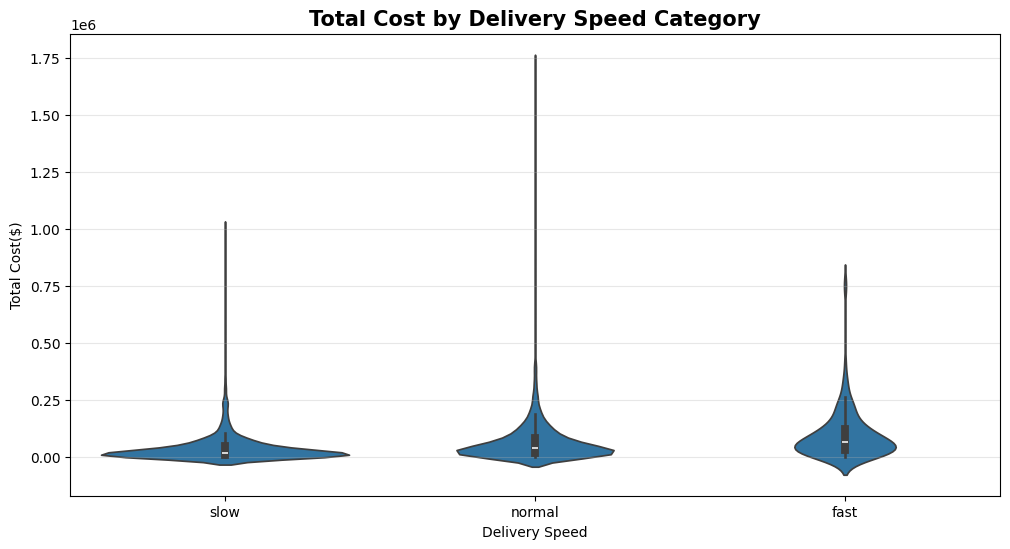

Yes, faster delivery cost more


In [192]:
# Analyze delivery_speed_category vs total_cost:
# • Create a violin plot

# Document the relationship found in each pair and what it means for the business.
plt.figure(figsize=(12,6))
sns.violinplot(data=df, x = 'Delivery_Speed_Category', y = 'total_cost')
plt.xlabel("Delivery Speed")
plt.ylabel("Total Cost($)")
plt.title("Total Cost by Delivery Speed Category",fontweight='bold', fontsize=15)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

# • Question: Do faster deliveries cost more?

avg_cost_by_days = df.groupby('days_to_deliver')['total_cost'].mean().round(0)
if avg_cost_by_days.iloc[0]>avg_cost_by_days[-1]:
    print("Yes, faster delivery cost more")
else:
    print("No, faster delivery doesn't cost more")

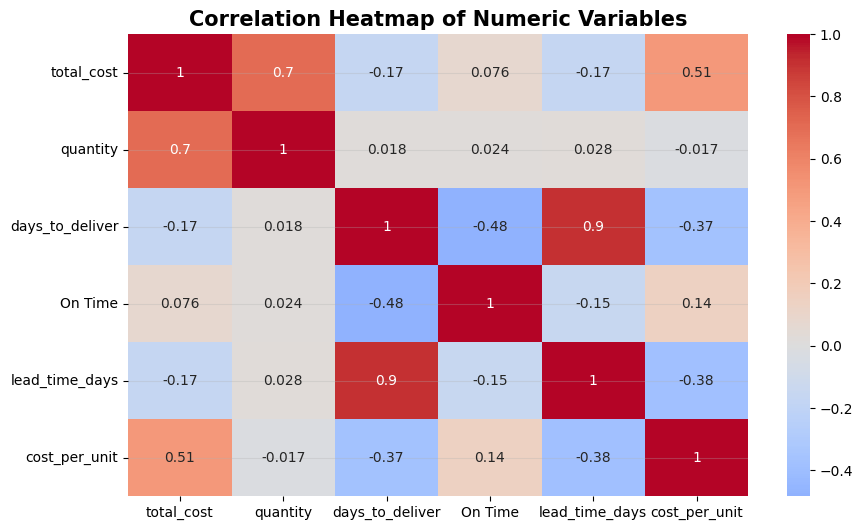

In [193]:
# Task 3: Multivariate Analysis - Complex Patterns
# Analyze patterns involving multiple variables.
# Create a heatmap showing correlations between all numeric variables:
# • total_cost, quantity, lead_time_days, days_to_deliver, on_time, cost_per_unit

numeric_col = ['total_cost','quantity','days_to_deliver','On Time','lead_time_days','cost_per_unit']
df_numeric =df[numeric_col]
corr_matrix = df_numeric.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Numeric Variables",fontweight='bold', fontsize=15)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

# • Question: Which variables are most strongly related?

In [194]:
# Create a pivot table showing average cost by supplier and product_category:

Supplier_product_Summary = df.pivot_table(
    values= 'total_cost',
    index= 'supplier_name',
    columns= 'product_category',
    aggfunc= 'mean'
).round(0)
Supplier_product_Summary.index.name = None
Supplier_product_Summary.columns.name = None

display(Supplier_product_Summary.fillna('-'))

# • Question: Which supplier-category combinations are cheapest?
Min_Cost =Supplier_product_Summary.min().min()
Cheapest = Supplier_product_Summary.stack().idxmin()

# • Which are most expensive? 
Max_Cost =Supplier_product_Summary.max().max()
Expensive = Supplier_product_Summary.stack().idxmax()

print(f"The cheapest supplier-category is {Cheapest[0]} for {Cheapest[1]} with an average cost of ${Min_Cost}")

print(f"The most expensive supplier-category is {Expensive[0]} for {Expensive[1]} with an average cost of ${Max_Cost}")

,Connectors,Control Systems,Fasteners,Hydraulics,Motors,Pumps,Sensors,Valves
Supplier A,-,89187.0,-,-,95224.0,-,-,-
Supplier B,-,-,-,-,100277.0,-,28569.0,26701.0
Supplier C,-,-,-,-,-,84223.0,26186.0,28114.0
Supplier D,-,-,-,52402.0,-,90795.0,-,-
Supplier E,9237.0,-,4886.0,-,-,-,-,-


The cheapest supplier-category is Supplier E for Fasteners with an average cost of $4886.0
The most expensive supplier-category is Supplier B for Motors with an average cost of $100277.0


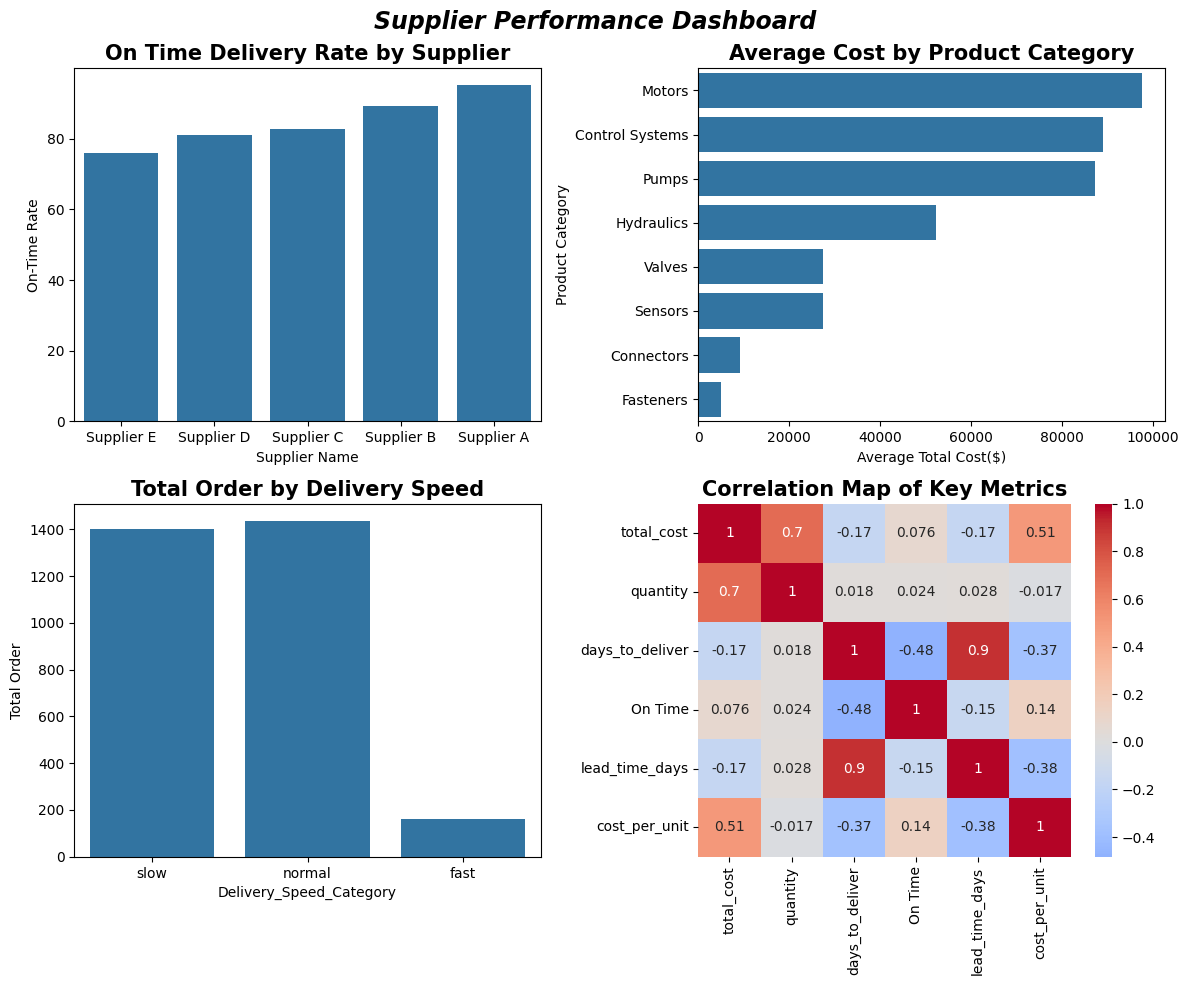

In [195]:
# Create a multi-panel visualization showing:
# • Subplot 1: On-time rate by supplier
# • Subplot 2: Average cost by product_category
# • Subplot 3: Order count by delivery_speed_category
# • Subplot 4: Correlation heatmap


fig, axes = plt.subplots(2,2, figsize=(12,10))
fig.suptitle("Supplier Performance Dashboard",fontweight='bold', fontsize=17, fontstyle='italic')
#On-time rate by supplier
ax1=axes[0,0]
ontime_by_supplier = df.groupby('supplier_name')['On Time'].mean().reset_index()
ontime_by_supplier['on_time_percentage']= ontime_by_supplier['On Time']*100
ontime_by_supplier = ontime_by_supplier.sort_values('on_time_percentage')
sns.barplot(data = ontime_by_supplier, x ='supplier_name',y ='on_time_percentage',  ax=ax1)
ax1.set_ylabel('On-Time Rate')
ax1.set_xlabel('Supplier Name')
ax1.set_title('On Time Delivery Rate by Supplier',fontweight='bold', fontsize=15)



#  Average cost by product_category
ax2 = axes[0,1]
avg_product_cost= df.groupby('product_category')['total_cost'].mean().reset_index()
avg_product_cost=avg_product_cost.sort_values('total_cost',ascending=False)
sns.barplot( data = avg_product_cost, y='product_category', x='total_cost', ax =ax2)
ax2.set_xlabel('Average Total Cost($)')
ax2.set_ylabel('Product Category')
ax2.set_title('Average Cost by Product Category',fontweight='bold', fontsize=15,)

#  Order count by delivery_speed_category
ax3 = axes[1,0]
sns.countplot(data=df, x= 'Delivery_Speed_Category', ax=ax3)
ax3.set_ylabel('Total Order')
ax3.set_xlabel('Delivery_Speed_Category')
ax3.set_title('Total Order by Delivery Speed',fontweight='bold', fontsize=15,)

#Correlation heatmap
ax4 = axes[1,1]
numeric_col = ['total_cost','quantity','days_to_deliver','On Time','lead_time_days','cost_per_unit']
corr_matrix = df_numeric.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax4)
axes[1,1].set_title('Correlation Map of Key Metrics',fontweight='bold', fontsize=15,)

plt.tight_layout()
plt.show()

# • Question: What patterns connect these different views?

In [196]:
# Analyze the relationship between delivery_speed_category and on_time:

# • Create a cross-tabulation showing count by both variables
table = pd.crosstab(df['Delivery_Speed_Category'], df['on_time'])
table.columns = ['Late', 'On Time']
table.index.name = 'Delivery Speed'
print("Table 1: Delivery Count by Speed Category and On Time Status")
print(table)
print()
print()
# • Are fast deliveries more likely to be on-time?
table_pct = pd.crosstab(df['Delivery_Speed_Category'], df['on_time'], normalize='index')*100
table_pct.columns = ['Late', 'On Time']
table_pct.index.name = 'Delivery Speed'
print("Table 2: On Time by Delivery Speed Category")
print(table_pct.round(1))
# • Question: Does speed category predict reliability?
chi2, p,dof,expected = chi2_contingency( pd.crosstab(df['Delivery_Speed_Category'], df['on_time']))
print(f"\nchi-square test result")
print(f"p-value:{p:.4f}")
if p_value < 0.05:
    print("Yes, speed category predicts realiablity")
else:
    print("No, speed category doesn't predicts realiablity")

Table 1: Delivery Count by Speed Category and On Time Status
                Late  On Time
Delivery Speed               
fast               5      157
normal            61     1376
slow             404      997


Table 2: On Time by Delivery Speed Category
                Late  On Time
Delivery Speed               
fast             3.1     96.9
normal           4.2     95.8
slow            28.8     71.2

chi-square test result
p-value:0.0000
Yes, speed category predicts realiablity


In [197]:
# Task 4: Anomaly Detection and Outlier Investigation
# Find unusual records worth investigating.
# Identify outliers in total_cost:
# • Use 3 standard deviations as threshold
average_cost =df['total_cost'].mean()
stan_dv_cost = df['total_cost'].std()
threshold = average_cost + 3 *stan_dv_cost
print(f"Mean Cost = ${average_cost:.0f}")
print(f"3 Std Dev Threshold = ${threshold:.0f}")
print()

# • Find records with costs above this threshold
total_cost_outlier = df[df['total_cost']>threshold]
print(f"Found {len(total_cost_outlier)} cost outliers")
print()

# • List the 5 most expensive orders with their details
top5_expensive = df.nlargest(5,'total_cost')[['supplier_name', 'product_category', 'total_cost', 'quantity','delivery_rate']]
print(top5_expensive)
print()
# • Question: Are these legitimate large orders or data errors?
top5_expensive['unit_price'] = top5_expensive['total_cost']/top5_expensive['quantity']
print("\nUnit Price Check:")
print(top5_expensive[['product_category', 'total_cost', 'quantity','unit_price']])

Mean Cost = $56679
3 Std Dev Threshold = $307375

Found 52 cost outliers

     supplier_name product_category  total_cost  quantity  delivery_rate
1584    Supplier B           Motors  1720595.40       489           89.0
1848    Supplier D            Pumps  1000681.24       403           81.0
2711    Supplier C            Pumps   991898.31       377           83.0
2492    Supplier A           Motors   807800.07       231           95.0
2147    Supplier A  Control Systems   765820.16       254           95.0


Unit Price Check:
     product_category  total_cost  quantity  unit_price
1584           Motors  1720595.40       489     3518.60
1848            Pumps  1000681.24       403     2483.08
2711            Pumps   991898.31       377     2631.03
2492           Motors   807800.07       231     3496.97
2147  Control Systems   765820.16       254     3015.04


In [198]:
# Identify outliers in delivery time:
mean_time =df['days_to_deliver'].mean()
std_time = df['days_to_deliver'].std()
deliver_outliers = df[abs(df['days_to_deliver']-mean_time)>3*std_time]
print(f"Mean Delivery:{mean_time:.1f}days") 
print(f"Standard Deviation:{std_time:.1f}days")
print()
print(f"Delivery Time Outliers:{len(deliver_outliers)} orders")
print()
print()
# • Find orders taking much longer than expected
# • List examples of each
high_limit = mean_time +3 * std_time
slow_outlier = df[df['days_to_deliver']>high_limit]
print(f"Orders taking much longer than expected = > {high_limit:.0f} days")
print(f"Count:{len(slow_outlier)} orders")
print(slow_outlier[['order_id','supplier_name','product_category','days_to_deliver','lead_time_days','On Time']].to_string(index=False)) 
print()
print()
# • Find orders delivered much faster than expected
# • List examples of each

low_limit = mean_time -3 * std_time
fast_order = df[df['days_to_deliver'] >=0]                 # removes - signs
fast = fast_order[fast_order['days_to_deliver'] < low_limit]
print(f"Orders delivered much faster than expected =  {len(fast)} orders")

if len(fast)  >0:
    print(fast[['order_id','supplier_name','product_category','days_to_deliver']])
else:
    print("No fast outliers found")
print()
print()


Mean Delivery:21.9days
Standard Deviation:11.9days

Delivery Time Outliers:12 orders


Orders taking much longer than expected = > 58 days
Count:12 orders
order_id supplier_name product_category  days_to_deliver  lead_time_days  On Time
ORD-0689    Supplier C            Pumps             59.0              41        0
ORD-1328    Supplier C            Pumps             61.0              46        0
ORD-1414    Supplier C          Sensors             59.0              46        0
ORD-1452    Supplier D       Hydraulics             61.0              41        0
ORD-1477    Supplier D            Pumps             61.0              43        0
ORD-1704    Supplier C            Pumps             65.0              45        0
ORD-1720    Supplier C            Pumps             58.0              50        0
ORD-1888    Supplier C            Pumps             60.0              52        0
ORD-2048    Supplier C            Pumps             59.0              40        0
ORD-2287    Supplier C   

In [199]:

# • Question: Why did these orders deviate so much?
slow_outlier['delay_gaps'] = slow_outlier['days_to_deliver'] - slow_outlier['lead_time_days']
print(slow_outlier[['order_id','supplier_name','product_category','days_to_deliver','lead_time_days','On Time','delay_gaps']].to_string(index=False)) 
print()
print(slow_outlier.groupby('supplier_name')[['days_to_deliver','lead_time_days','delay_gaps']].mean())
print()
print(slow_outlier.groupby('product_category')[['days_to_deliver','lead_time_days','delay_gaps']].mean())
print()
print()
print("The slow order happened because Supplier C & D took 15-20 days longer than expected for Pumps, Sensors ans Hydraulics")

order_id supplier_name product_category  days_to_deliver  lead_time_days  On Time  delay_gaps
ORD-0689    Supplier C            Pumps             59.0              41        0        18.0
ORD-1328    Supplier C            Pumps             61.0              46        0        15.0
ORD-1414    Supplier C          Sensors             59.0              46        0        13.0
ORD-1452    Supplier D       Hydraulics             61.0              41        0        20.0
ORD-1477    Supplier D            Pumps             61.0              43        0        18.0
ORD-1704    Supplier C            Pumps             65.0              45        0        20.0
ORD-1720    Supplier C            Pumps             58.0              50        0         8.0
ORD-1888    Supplier C            Pumps             60.0              52        0         8.0
ORD-2048    Supplier C            Pumps             59.0              40        0        19.0
ORD-2287    Supplier C            Pumps             59.0    

In [200]:
# Identify potential data quality issues:
# • Find orders where days_to_deliver doesn't match lead_time_days reasonably
unusual_match = df[df['days_to_deliver'] >=0] 
unusual_match = unusual_match[abs(unusual_match['days_to_deliver'] - unusual_match['lead_time_days'])>1]
print(unusual_match[['order_id', 'supplier_name','lead_time_days', 'days_to_deliver']])
print()
# • Find orders with zero quantity or cost
zero = df[(df['quantity']==0) | (df['total_cost']==0)]
print(f"Zero quantity or cost: {len(zero)} orders")
if len(zero) >0:
    print(zero[['order_id', 'supplier_name', 'quantity', 'total_cost']].head(10))
print()

# • Find any supplier with suspiciously inconsistent performance
supplier_status = df[df['days_to_deliver']>0].groupby('supplier_name')['days_to_deliver'].agg(['mean','std', 'count'])
inconsistent = supplier_status[(supplier_status['std'] > supplier_status['mean']) & (supplier_status['count']>3)]
print(f"Inconsistent supplier: {len(inconsistent)}")
if len(inconsistent)>0:
    print(inconsistent.sort_values('std', ascending=False))
pd.set_option('display.max_rows',500)

# • Document findings



      order_id supplier_name  lead_time_days  days_to_deliver
18    ORD-0019    Supplier D              32             37.0
19    ORD-0020    Supplier D              28             33.0
27    ORD-0028    Supplier E              22             39.0
56    ORD-0057    Supplier E              28             38.0
85    ORD-0086    Supplier E              15             30.0
88    ORD-0089    Supplier D              34             41.0
90    ORD-0091    Supplier E              16             35.0
96    ORD-0097    Supplier D              35             48.0
105   ORD-0106    Supplier E              26             33.0
108   ORD-0109    Supplier C              24             41.0
110   ORD-0111    Supplier D              22             29.0
113   ORD-0114    Supplier D              39             54.0
128   ORD-0129    Supplier E              26             35.0
131   ORD-0132    Supplier A              12             20.0
141   ORD-0142    Supplier B              13             18.0
142   OR

In [201]:
# Investigate patterns in anomalies:
# • Do anomalies cluster by supplier, product, or time period?
anomalies = unusual_match
print(anomalies['supplier_name'].value_counts())
print()
print(anomalies['product_category'].value_counts())
print()
# • Are anomalies random or systematic?

supplier_name
Supplier E    155
Supplier C     85
Supplier D     82
Supplier B     71
Supplier A     37
Name: count, dtype: int64

product_category
Connectors         93
Fasteners          62
Pumps              62
Hydraulics         51
Motors             49
Sensors            47
Valves             43
Control Systems    23
Name: count, dtype: int64



In [202]:
print(anomalies['month'].value_counts())

month
Nov    47
Jan    43
Jul    39
Apr    37
May    37
Sep    37
Oct    35
Mar    34
Aug    34
Feb    33
Dec    28
Jun    26
Name: count, dtype: int64


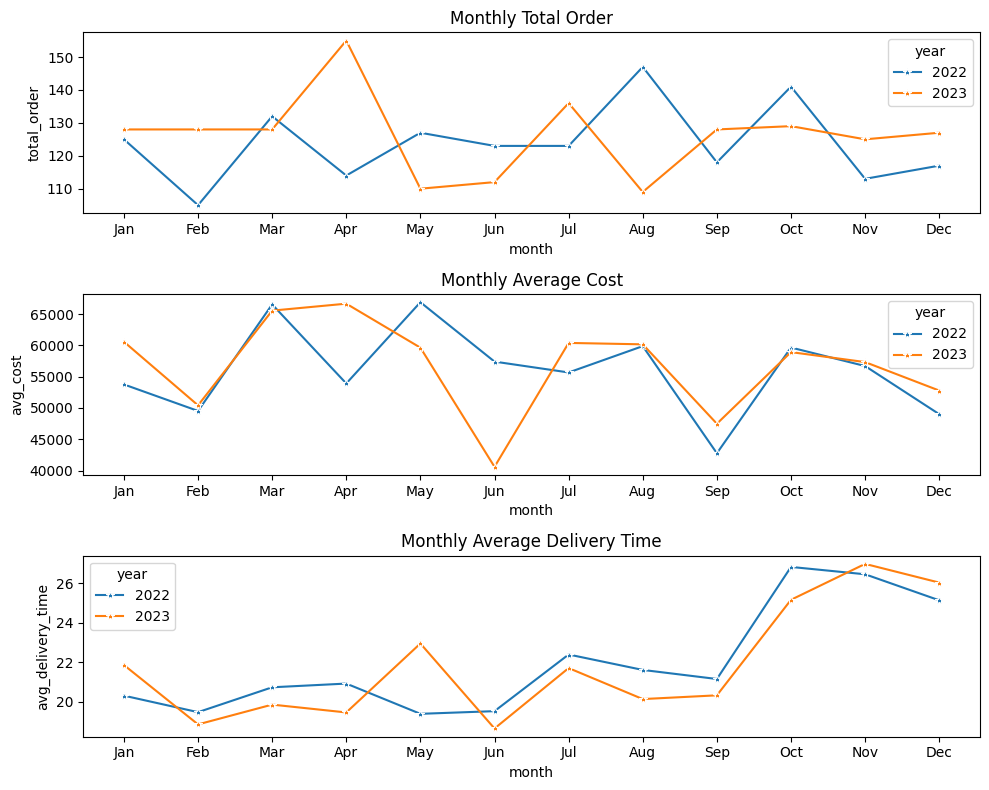

In [203]:
# Task 4
# Create a temporal analysis.
# • Do order patterns, costs, or delivery performance change over time?
# • Extract month and year from order_date and analyze trends.
# • Are things improving or degrading?

# • Extract month and year from order_date and analyze trends.
df['year'] = pd.to_datetime(df['order_date']).dt.year
df['year'] = df['year'].astype(str)
df['month'] =df['month'].astype(str)

# keep month in its order
month_order =['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)

# • Do order patterns, costs, or delivery performance change over time?
monthly_trend = df.groupby(['year','month']).agg({
    'order_id':'count',
    'total_cost':'mean',
    'days_to_deliver':'mean'
}).reset_index()
monthly_trend.columns=['year','month', 'total_order', 'avg_cost', 'avg_delivery_time']

plt.figure(figsize=(10,8))
plt.subplot(3,1,1)
sns.lineplot(data=monthly_trend, x='month', y='total_order',hue='year',marker='*')
plt.title('Monthly Total Order')

plt.subplot(3,1,2)
sns.lineplot(data=monthly_trend, x='month', y='avg_cost',hue='year',marker='*')
plt.title('Monthly Average Cost')

plt.subplot(3,1,3)
sns.lineplot(data=monthly_trend, x='month', y='avg_delivery_time',hue='year',marker='*')
plt.title('Monthly Average Delivery Time')

plt.tight_layout()
plt.show()



Delivery_Speed_Category      fast    normal      slow
size_category                                        
large                    765820.0  682449.0  632918.0
medium                   211325.0  156811.0   95606.0
small                     53433.0   47432.0   26265.0


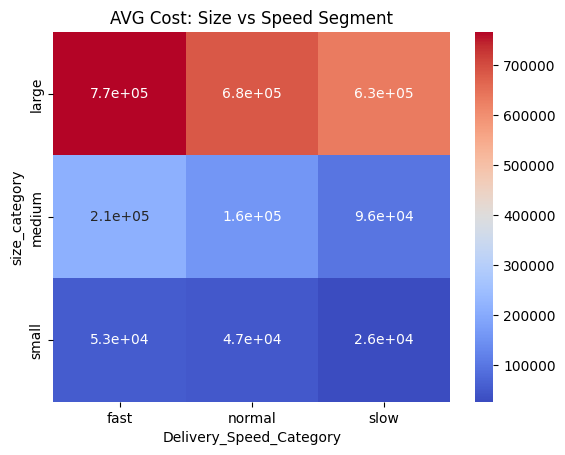

In [204]:

# Task 5
# Create a customer/order behavior segmentation.
# • Group orders by characteristics (size, cost, speed) and identify distinct segments.
# • Do different segments have different characteristics?
# • What patterns define each segment?

customer_order_behaviour = df.pivot_table(
    index='size_category',
    columns='Delivery_Speed_Category',
    values='total_cost',
    aggfunc='mean'
).round(0)

print(customer_order_behaviour)

sns.heatmap(customer_order_behaviour, annot=True, cmap='coolwarm')
plt.title('AVG Cost: Size vs Speed Segment')
plt.show()

In [205]:
# Task 6
# Create a root cause analysis of late deliveries.For orders that were late, investigate:
# • Which suppliers are responsible?
# • Which products?
# • Which time periods?
# • Is there a systematic cause?

df['late_delivery']= df['days_to_deliver'] > df['lead_time_days']
late = df[df['late_delivery']]

supplier_delay = late.groupby('supplier_name').size().sort_values(ascending=False)

product_delay = late.groupby('product_category').size().sort_values(ascending=False)


time_delay = late.groupby(['year','month']).size()

print(supplier_delay.head())
print()
print(product_delay.head())
print()
print(time_delay.head())

supplier_name
Supplier E    155
Supplier C     85
Supplier D     82
Supplier B     71
Supplier A     37
dtype: int64

product_category
Connectors    93
Fasteners     62
Pumps         62
Hydraulics    51
Motors        49
dtype: int64

year  month
2022  Jan      23
      Feb      14
      Mar      16
      Apr      22
      May      19
dtype: int64
